# HR 離職風險分析 — People Analytics 作品集

> IBM HR Analytics Attrition Dataset｜作者：Tommy｜建置日期：2026-04-18
>
> 本 Notebook 針對 IBM HR Attrition 公開資料集，建立 **可解釋、可落地** 的離職風險預測模型。
> 不同於一般 Kaggle 式教學，本版強化四大能力：
>
> 1. **SHAP 可解釋性** — TreeExplainer + summary / waterfall / dependence plots
> 2. **豐富的 Feature Engineering** — 新增 4 個 HR 複合指標
> 3. **嚴謹的模型評估** — 以 PR-AUC 為主要指標、ECE 校準、Lift Table
> 4. **Monitoring Layer** — 輸出具體 HR 介入建議，不只是風險標籤
>
> 每個 section 同時服務兩種讀者：
> - **Data Science reviewer**：需要技術嚴謹性與正當的建模選擇
> - **People Analytics / HR reviewer**：需要業務框架與可行動的輸出

## Section 0 — Setup & Imports

建立分析環境：載入核心套件、設定 matplotlib 繁體中文字型、定義共用色彩主題與 helper functions。

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager

# 模型與評估
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 可解釋性 & 平滑曲線
import shap
import statsmodels.api as sm
import xgboost as xgb

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# 常數
DATA_PATH = Path("Data/附件_資料分析資料集.csv")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

In [ ]:
# ── THEME 色彩字典 ─────────────────────────────────────────────
THEME = {
    "primary": "#2E86AB",       # 深藍 — 留任 / 主色
    "risk": "#E63946",          # 紅色 — 離職 / 風險
    "accent": "#F4A261",        # 橘色 — 強調
    "neutral": "#6C757D",       # 灰 — 中性
    "success": "#52B788",       # 綠 — 健康
    "warning": "#E9C46A",       # 黃 — 警示
    "bg_card": "#F8F9FA",       # 卡片背景
    "text_dark": "#212529",
    "text_light": "#6C757D",
    "divider": "#DEE2E6",
}
ATTR_PALETTE = {"No": THEME["primary"], "Yes": THEME["risk"]}

# ── matplotlib 繁體中文字型設定 ────────────────────────────────
def _setup_cjk_font() -> str:
    """選擇可用的繁中字型（Noto Sans TC 優先）。"""
    candidates = ["Noto Sans TC", "Noto Sans CJK TC", "PingFang TC", "Microsoft JhengHei", "Heiti TC"]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            return name
    return "DejaVu Sans"


CJK_FONT = _setup_cjk_font()

# ⚠️ 注意順序：seaborn.set_style() 會覆寫 font.family，必須先 set_style 再更新 rcParams
sns.set_style("whitegrid", {"grid.color": THEME["divider"], "grid.linestyle": "--"})

mpl.rcParams.update({
    "font.family": [CJK_FONT, "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.dpi": 110,
    "savefig.dpi": 140,
    "figure.figsize": (10, 5.5),
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})

In [3]:
# ── Helper Functions ──────────────────────────────────────────
def kpi_card(ax, title: str, value: str, subtitle: str, color: str = THEME["primary"]) -> None:
    """在指定 Axes 上繪製一個 KPI 卡片。"""
    ax.set_facecolor(THEME["bg_card"])
    ax.text(0.5, 0.78, title, ha="center", va="center",
            fontsize=11, color=THEME["text_light"], weight="bold")
    ax.text(0.5, 0.48, value, ha="center", va="center",
            fontsize=26, color=color, weight="bold")
    ax.text(0.5, 0.18, subtitle, ha="center", va="center",
            fontsize=9, color=THEME["text_dark"], style="italic")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(THEME["divider"]); spine.set_linewidth(1.2)


def annotate_bars(ax, fmt: str = "{:.1%}", offset: float = 0.0, fontsize: int = 9) -> None:
    """在長條圖上方加註數值標籤。"""
    for p in ax.patches:
        height = p.get_height()
        if np.isnan(height) or height == 0:
            continue
        ax.annotate(
            fmt.format(height),
            (p.get_x() + p.get_width() / 2, height + offset),
            ha="center", va="bottom", fontsize=fontsize, color=THEME["text_dark"],
        )


def section_header(title: str, subtitle: str = "") -> None:
    """印出 section 分隔線（純文字，用於 cell 輸出）。"""
    line = "═" * 70
    print(f"\n{line}\n{title}\n{line}")
    if subtitle:
        print(subtitle)


def pct(x: float) -> str:
    return f"{x * 100:.1f}%"


print(f"✓ CJK font selected: {CJK_FONT}")
print(f"✓ pandas {pd.__version__} · numpy {np.__version__} · sklearn 已載入")
print(f"✓ xgboost {xgb.__version__} · shap {shap.__version__}")
print("\nEnvironment ready")

✓ CJK font selected: Noto Sans TC
✓ pandas 2.3.3 · numpy 2.3.5 · sklearn 已載入
✓ xgboost 3.2.0 · shap 0.51.0

Environment ready


## Section 1 — Business Context

### 管理層關心的 4 個問題

1. **誰最可能離職？** — 建立可排名的個人層級風險分數，讓 HR 能針對高風險員工優先介入。
2. **為什麼會離職？** — 不只給風險分數，還要給出**每位員工的首要風險因子**（Primary Risk Factor），使主管知道該談什麼。
3. **哪些部門／職位／任期段是結構性高風險區？** — 把焦點從「救火」轉移到「重新設計流程與政策」。
4. **模型建議是否公平？** — 檢視不同性別、年齡段、婚姻狀態的風險分布是否存在顯著偏差，避免自動化決策造成歧視。

### 為什麼這份分析不同？

本報告不滿足於 Kaggle 式的「跑一個模型、報一個 ROC-AUC」：

- **評估指標改以 PR-AUC 為主**：因離職屬於少數類別（約 16%），ROC-AUC 會被大量真負案例抬高而失真。PR-AUC 衡量的是模型在「正類（離職）」上的精準排序能力，才是 HR 真正關心的——「風險名單前 10% 的員工，離職率是不是真的比較高？」
- **機率校準（Calibration）**：一個「預測機率 70%」的員工，在真實世界中是不是真的有 70% 的離職機率？我們以 ECE（Expected Calibration Error）量化，並透過 Sigmoid/Isotonic 校準讓機率可直接作為預算排序依據。
- **SHAP 可解釋性**：對每一位高風險員工，明確指出「推升他風險的前三個因素」。這是 HR 與員工進行 stay interview 時的談話起點，不只是黑箱分數。
- **Monitoring Layer 給的是「建議動作」，不是「標籤」**：Intervention Queue 包含 `PrimarySignal`、`SuggestedAction`、`ReviewCadence`，讓 HR 能直接執行。

### 分析限制（誠實揭露）

- IBM HR Attrition 為**合成資料集**，變數關係不代表真實人資分布；模型只能展示**方法論**，不能外推到實際組織。
- 資料僅呈現離職「結果」，不含離職原因問卷、主管評語等文字資料，因此 SHAP 找到的驅動因子屬**相關**而非**因果**。
- 資料為**單一時間切片**（cross-sectional snapshot），無法建立存活分析（survival analysis）或時序動態模型。

## Section 2 — Dataset Intake

載入原始資料，檢視 schema 與前幾筆樣本。

In [4]:
df_raw = pd.read_csv(DATA_PATH)

section_header("Dataset Snapshot")
print(f"資料列數（員工數）: {df_raw.shape[0]:,}")
print(f"資料欄數            : {df_raw.shape[1]}")
print(f"記憶體占用          : {df_raw.memory_usage(deep=True).sum() / 1024:,.1f} KB")
print(f"目標變數 Attrition  : {dict(df_raw['Attrition'].value_counts())}")
print(f"離職率 (Yes 占比)   : {pct((df_raw['Attrition'] == 'Yes').mean())}")


══════════════════════════════════════════════════════════════════════
Dataset Snapshot
══════════════════════════════════════════════════════════════════════
資料列數（員工數）: 1,470
資料欄數            : 35
記憶體占用          : 1,040.5 KB
目標變數 Attrition  : {'No': np.int64(1233), 'Yes': np.int64(237)}
離職率 (Yes 占比)   : 16.1%


In [5]:
schema = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "non_null": df_raw.notna().sum(),
    "n_unique": df_raw.nunique(),
    "sample": [df_raw[c].dropna().iloc[0] if df_raw[c].notna().any() else None for c in df_raw.columns],
})
schema.index.name = "column"
section_header("Schema (dtype / 非空數 / 唯一值數 / 樣本)")
schema


══════════════════════════════════════════════════════════════════════
Schema (dtype / 非空數 / 唯一值數 / 樣本)
══════════════════════════════════════════════════════════════════════


,dtype,non_null,n_unique,sample
column,,,,
Age,int64,1470,43,41
Attrition,object,1470,2,Yes
BusinessTravel,object,1470,3,Travel_Rarely
DailyRate,int64,1470,886,1102
Department,object,1470,3,Sales
DistanceFromHome,int64,1470,29,1
Education,int64,1470,5,2
EducationField,object,1470,6,Life Sciences
EmployeeCount,int64,1470,1,1


In [6]:
section_header("前 8 筆資料（抽樣檢視）")
df_raw.head(8)


══════════════════════════════════════════════════════════════════════
前 8 筆資料（抽樣檢視）
══════════════════════════════════════════════════════════════════════


column,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0


**關於這份資料集**

IBM HR Analytics Attrition 是 IBM 資料科學家**刻意合成**的公開教學資料集，並非真實公司員工紀錄。它的優點是欄位完整、乾淨、無缺失值，適合展示方法論；缺點是變數間的關係可能有人為設計的偏差，因此本分析中的特定係數與驅動因子結論**不具外推性**。

本分析的價值在於：
- 展示一套**可複製的 People Analytics 方法論**（資料品質檢查 → EDA → FE → 建模 → 可解釋性 → Monitoring）
- 在 HR 組織導入此方法時，可將 pipeline 直接套用於真實 HRIS 資料（Workday、SAP SuccessFactors 等）

## Section 3 — Data Quality Gate

在進入建模前，先通過三道品質檢查：**缺失值**、**重複列**、**常數欄位**。若資料不乾淨，後續所有結論都不可信。

In [7]:
missing = df_raw.isna().sum()
missing = missing[missing > 0]
duplicates = df_raw.duplicated().sum()

constant_cols = [c for c in df_raw.columns if df_raw[c].nunique(dropna=False) <= 1]

section_header("Data Quality Checks")
print(f"缺失值欄位數        : {len(missing)}  {'(none)' if len(missing)==0 else dict(missing)}")
print(f"重複列數            : {duplicates}")
print(f"常數欄位（需移除）  : {constant_cols}")
print(f"  常數值 → {[df_raw[c].iloc[0] for c in constant_cols]}")


══════════════════════════════════════════════════════════════════════
Data Quality Checks
══════════════════════════════════════════════════════════════════════
缺失值欄位數        : 0  (none)
重複列數            : 0
常數欄位（需移除）  : ['EmployeeCount', 'Over18', 'StandardHours']
  常數值 → [np.int64(1), 'Y', np.int64(80)]


In [8]:
# 產生乾淨資料集：移除常數欄位、保留員工編號為索引參考
df = df_raw.drop(columns=constant_cols).copy()

# 目標變數轉 0/1（Yes=1 離職、No=0 留任）
df["AttritionFlag"] = (df["Attrition"] == "Yes").astype(int)

section_header("清理後資料集形狀")
print(f"形狀              : {df.shape}")
print(f"移除欄位          : {constant_cols}")
print(f"新增目標欄位      : AttritionFlag（0=留任, 1=離職）")

analytic_ready = len(missing) == 0 and duplicates == 0
verdict = "✅ READY" if analytic_ready else "⚠️ NOT READY — 需先處理資料品質問題"
print(f"\nAnalytic Readiness Verdict : {verdict}")


══════════════════════════════════════════════════════════════════════
清理後資料集形狀
══════════════════════════════════════════════════════════════════════
形狀              : (1470, 33)
移除欄位          : ['EmployeeCount', 'Over18', 'StandardHours']
新增目標欄位      : AttritionFlag（0=留任, 1=離職）

Analytic Readiness Verdict : ✅ READY


## Section 4 — Executive KPIs

6 個給管理層的一目了然指標。每個指標下方附一句話業務詮釋，確保 HR Director 能在 30 秒內掌握組織人力健康度。

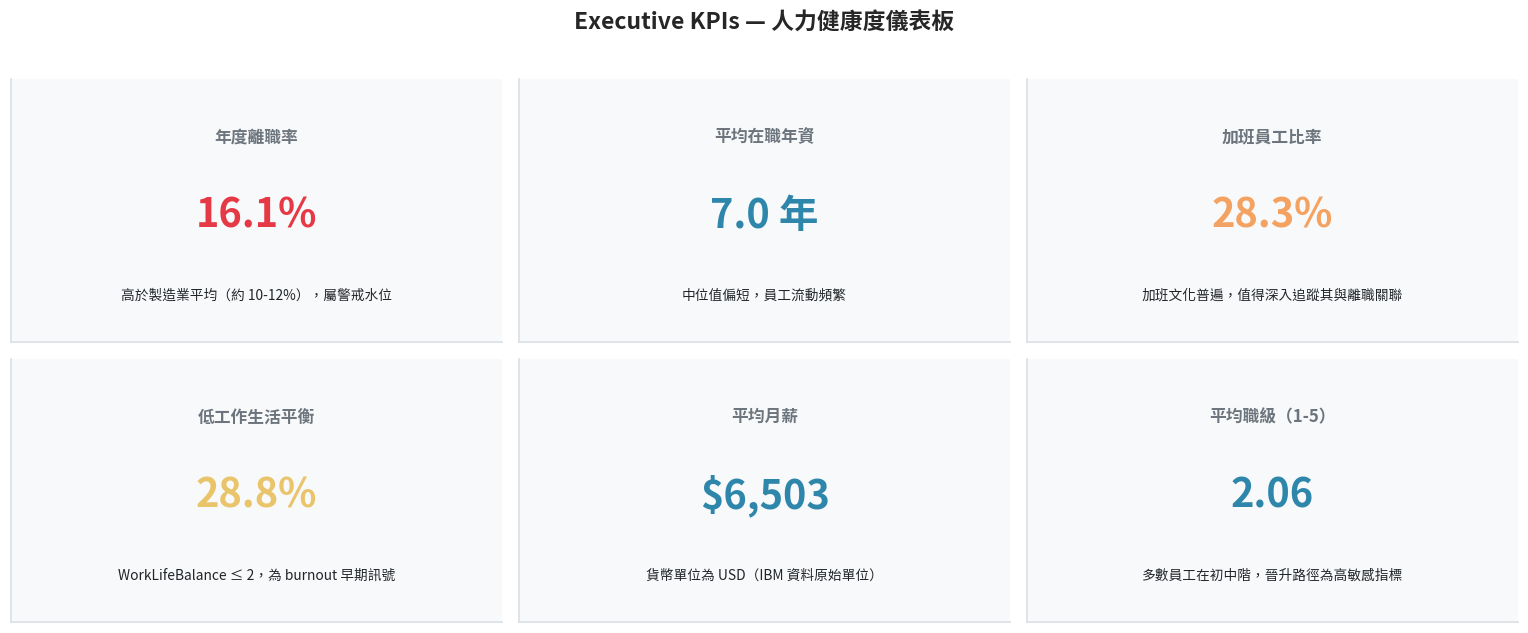

In [9]:
overall_attr_rate = df["AttritionFlag"].mean()
avg_tenure        = df["YearsAtCompany"].mean()
overtime_rate     = (df["OverTime"] == "Yes").mean()
low_wlb_rate      = (df["WorkLifeBalance"] <= 2).mean()
avg_income        = df["MonthlyIncome"].mean()
avg_joblevel      = df["JobLevel"].mean()

# 每個 card 的色彩依「健康度」決定：紅=風險警訊、藍=中性參考、綠=健康
cards = [
    {"title": "年度離職率",        "value": pct(overall_attr_rate),    "subtitle": "高於製造業平均（約 10-12%），屬警戒水位",      "color": THEME["risk"]},
    {"title": "平均在職年資",      "value": f"{avg_tenure:.1f} 年",    "subtitle": "中位值偏短，員工流動頻繁",                     "color": THEME["primary"]},
    {"title": "加班員工比率",      "value": pct(overtime_rate),        "subtitle": "加班文化普遍，值得深入追蹤其與離職關聯",       "color": THEME["accent"]},
    {"title": "低工作生活平衡",    "value": pct(low_wlb_rate),         "subtitle": "WorkLifeBalance ≤ 2，為 burnout 早期訊號",     "color": THEME["warning"]},
    {"title": "平均月薪",          "value": f"${avg_income:,.0f}",     "subtitle": "貨幣單位為 USD（IBM 資料原始單位）",           "color": THEME["primary"]},
    {"title": "平均職級（1-5）",    "value": f"{avg_joblevel:.2f}",     "subtitle": "多數員工在初中階，晉升路徑為高敏感指標",       "color": THEME["primary"]},
]

fig, axes = plt.subplots(2, 3, figsize=(14, 5.6))
fig.patch.set_facecolor("white")
for ax, card in zip(axes.flat, cards):
    kpi_card(ax, **card)
fig.suptitle("Executive KPIs — 人力健康度儀表板", fontsize=15, weight="bold", y=1.02)
plt.tight_layout(); plt.show()

## Section 5 — Diagnostic EDA

目標：找出**哪些變數與離職有明確關聯**，作為後續 Feature Engineering 與 Monitoring 的依據。

每張圖同時回答兩個問題：
- **DS reviewer**：變數分布是否健康？是否存在潛在多重共線性？
- **HR reviewer**：這個現象對人資管理實務意味著什麼？

### 5.1 關鍵數值變數分布（離職 vs 留任）

觀察 Age、MonthlyIncome、YearsAtCompany、DistanceFromHome 四個變數在兩類員工間的分布差異。
**HR 意涵**：找出「離職員工的人口學輪廓」。

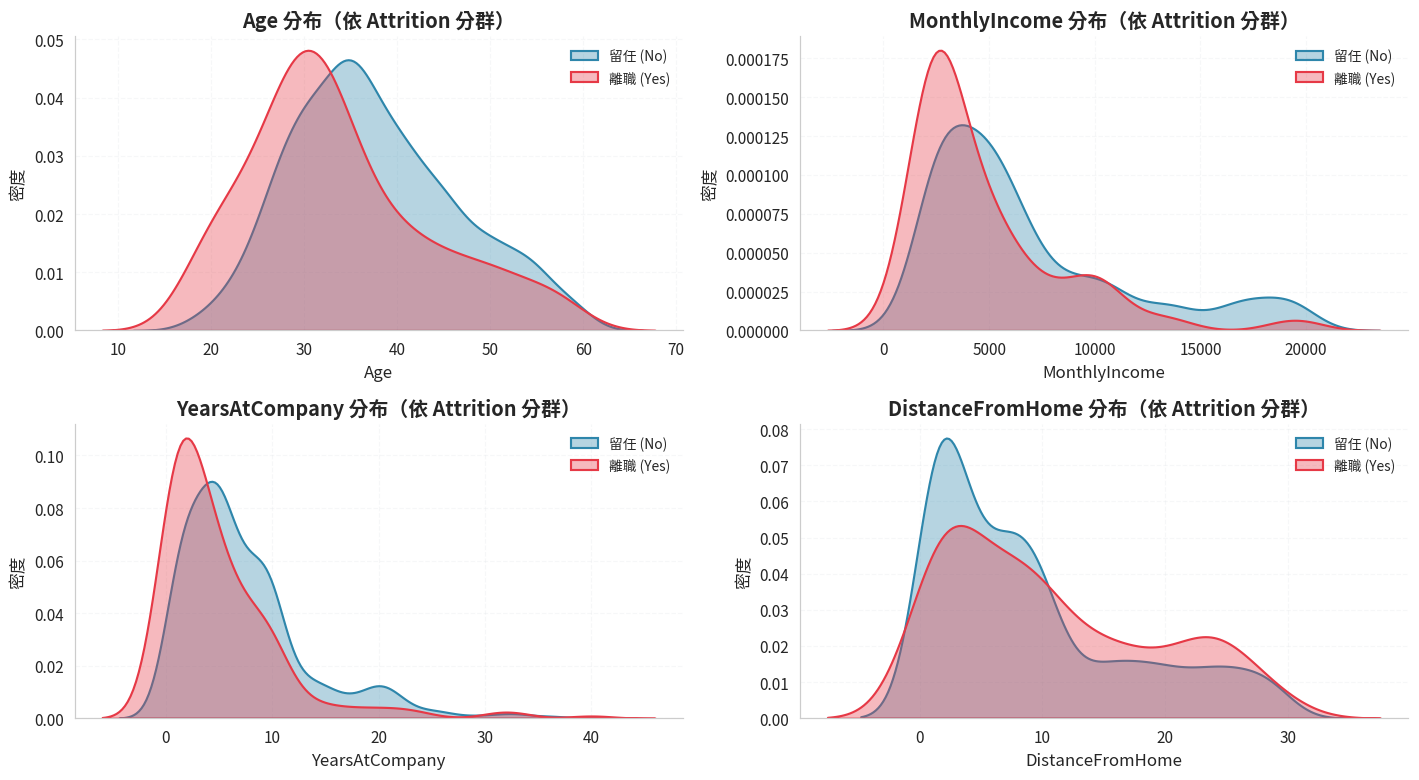


平均值比較（留任 vs 離職）
column      Age  MonthlyIncome  YearsAtCompany  DistanceFromHome
Attrition                                                       
No         37.6         6832.7             7.4               8.9
Yes        33.6         4787.1             5.1              10.6


In [10]:
numeric_focus = ["Age", "MonthlyIncome", "YearsAtCompany", "DistanceFromHome"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7.2))
for ax, col in zip(axes.flat, numeric_focus):
    for flag, label, color in [(0, "留任 (No)", THEME["primary"]), (1, "離職 (Yes)", THEME["risk"])]:
        sns.kdeplot(df.loc[df["AttritionFlag"] == flag, col], ax=ax,
                    fill=True, alpha=0.35, color=color, label=label, linewidth=1.4)
    ax.set_title(f"{col} 分布（依 Attrition 分群）")
    ax.set_xlabel(col); ax.set_ylabel("密度")
    ax.legend(loc="best", fontsize=9)
plt.tight_layout(); plt.show()

# 同時印出統計差異
stats = df.groupby("Attrition")[numeric_focus].mean().round(1)
print("\n平均值比較（留任 vs 離職）")
print(stats)

### 5.2 類別變數與離職率（OverTime、BusinessTravel、MaritalStatus、Department）

比較不同群組的離職率差異，找出「結構性高風險區」。

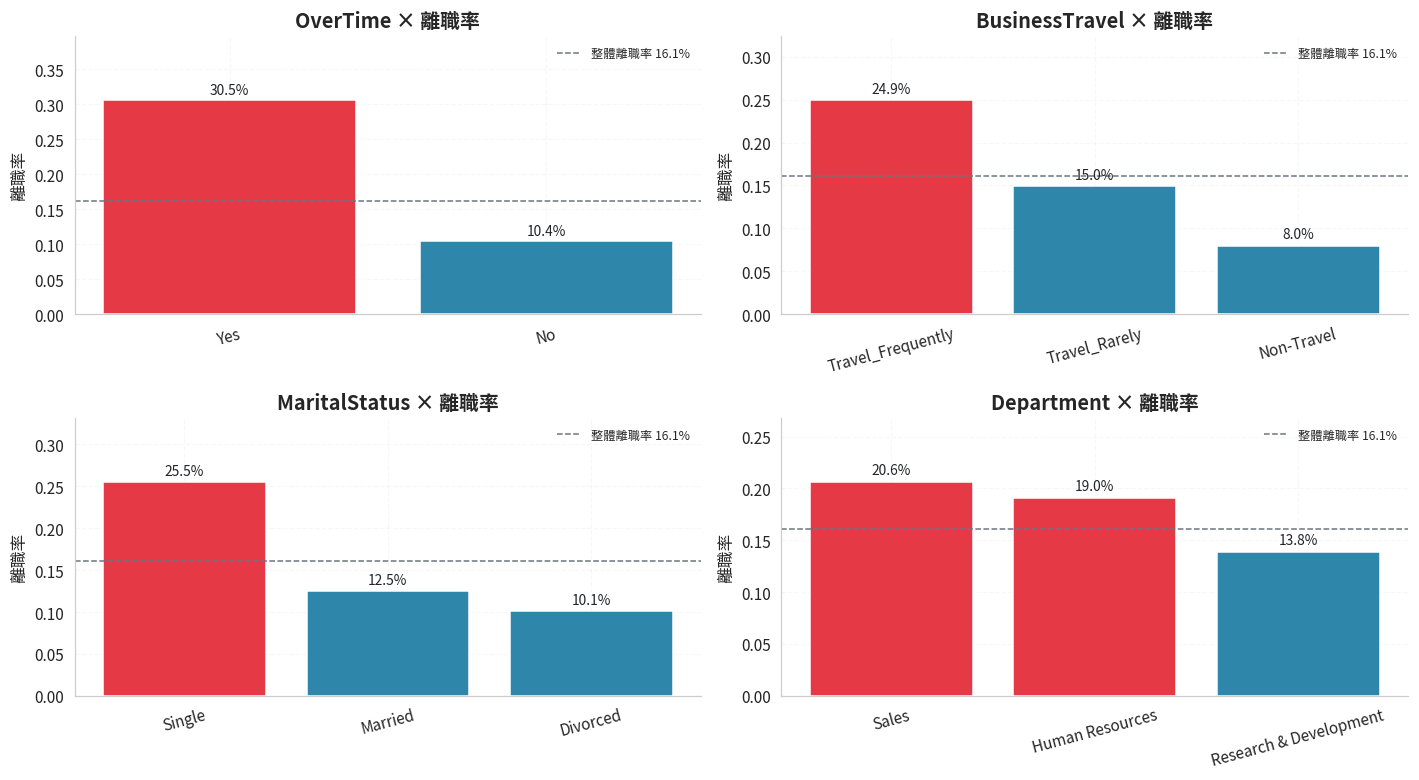

In [11]:
cat_focus = ["OverTime", "BusinessTravel", "MaritalStatus", "Department"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7.2))
for ax, col in zip(axes.flat, cat_focus):
    rate = df.groupby(col)["AttritionFlag"].mean().sort_values(ascending=False)
    bars = ax.bar(rate.index, rate.values,
                  color=[THEME["risk"] if v > overall_attr_rate else THEME["primary"] for v in rate.values],
                  edgecolor="white", linewidth=1)
    ax.axhline(overall_attr_rate, linestyle="--", color=THEME["neutral"],
               linewidth=1, label=f"整體離職率 {pct(overall_attr_rate)}")
    ax.set_title(f"{col} × 離職率")
    ax.set_ylabel("離職率")
    ax.set_ylim(0, max(rate.values) * 1.3)
    ax.legend(loc="upper right", fontsize=8)
    ax.tick_params(axis="x", rotation=15)
    annotate_bars(ax, fmt="{:.1%}", offset=0.005, fontsize=9)
plt.tight_layout(); plt.show()

### 5.3 年齡與任期 vs 離職率（LOWESS 趨勢線）

用 LOWESS 平滑連續變數與離職率的關係，避免硬切 bin 造成的偽趨勢。
**HR 意涵**：找出「任期與年齡的高風險拐點」。

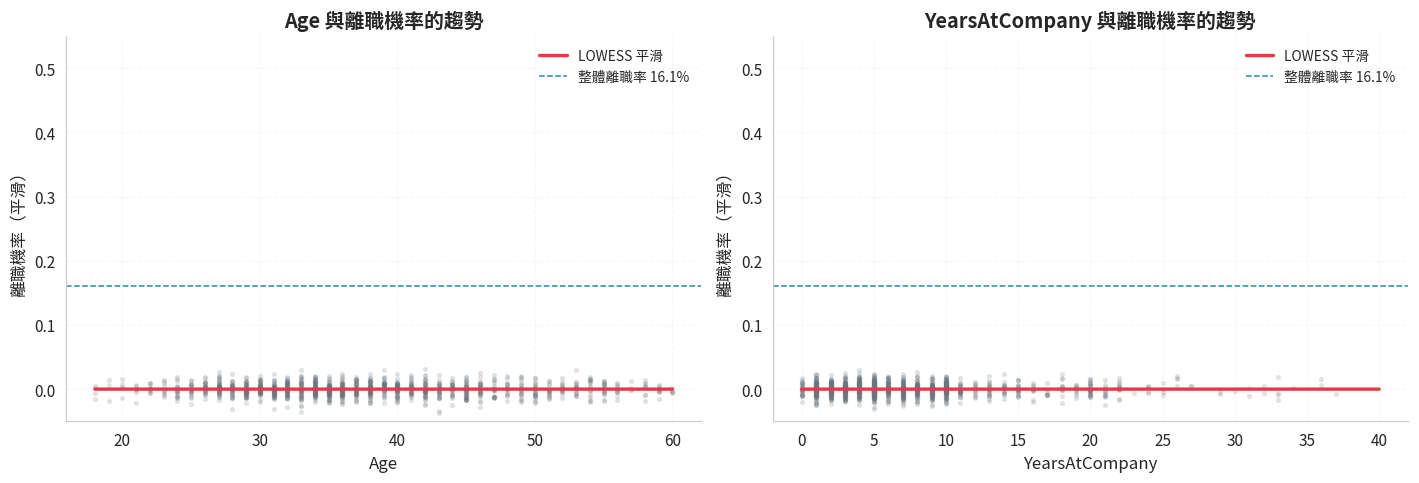

In [12]:
lowess = sm.nonparametric.lowess

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col in zip(axes, ["Age", "YearsAtCompany"]):
    smoothed = lowess(df["AttritionFlag"], df[col], frac=0.35, return_sorted=True)
    # 散點（抖動顯示）
    jitter = np.random.normal(0, 0.01, size=len(df))
    ax.scatter(df[col], df["AttritionFlag"] + jitter, s=6, alpha=0.15, color=THEME["neutral"])
    ax.plot(smoothed[:, 0], smoothed[:, 1], color=THEME["risk"], linewidth=2.2, label="LOWESS 平滑")
    ax.axhline(overall_attr_rate, linestyle="--", color=THEME["primary"], linewidth=1,
               label=f"整體離職率 {pct(overall_attr_rate)}")
    ax.set_title(f"{col} 與離職機率的趨勢")
    ax.set_xlabel(col); ax.set_ylabel("離職機率（平滑）")
    ax.set_ylim(-0.05, 0.55)
    ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()

### 5.4 序數（Likert）欄位與離職率

這些欄位本質是**有序類別變數**（Likert 1-4 或 1-5），雖然資料型態是整數，但不應視為連續數值進入相關性矩陣。
將每個 Likert 等級的離職率獨立繪製，呈現滿意度／投入度的梯度效應。

> **注意**：PerformanceRating 僅有 3 與 4 兩個實際值（即所有員工都是「好」或「優秀」），variance 過低，對建模幾乎無貢獻，因此圖中標註說明，後續建模保留為弱訊號。

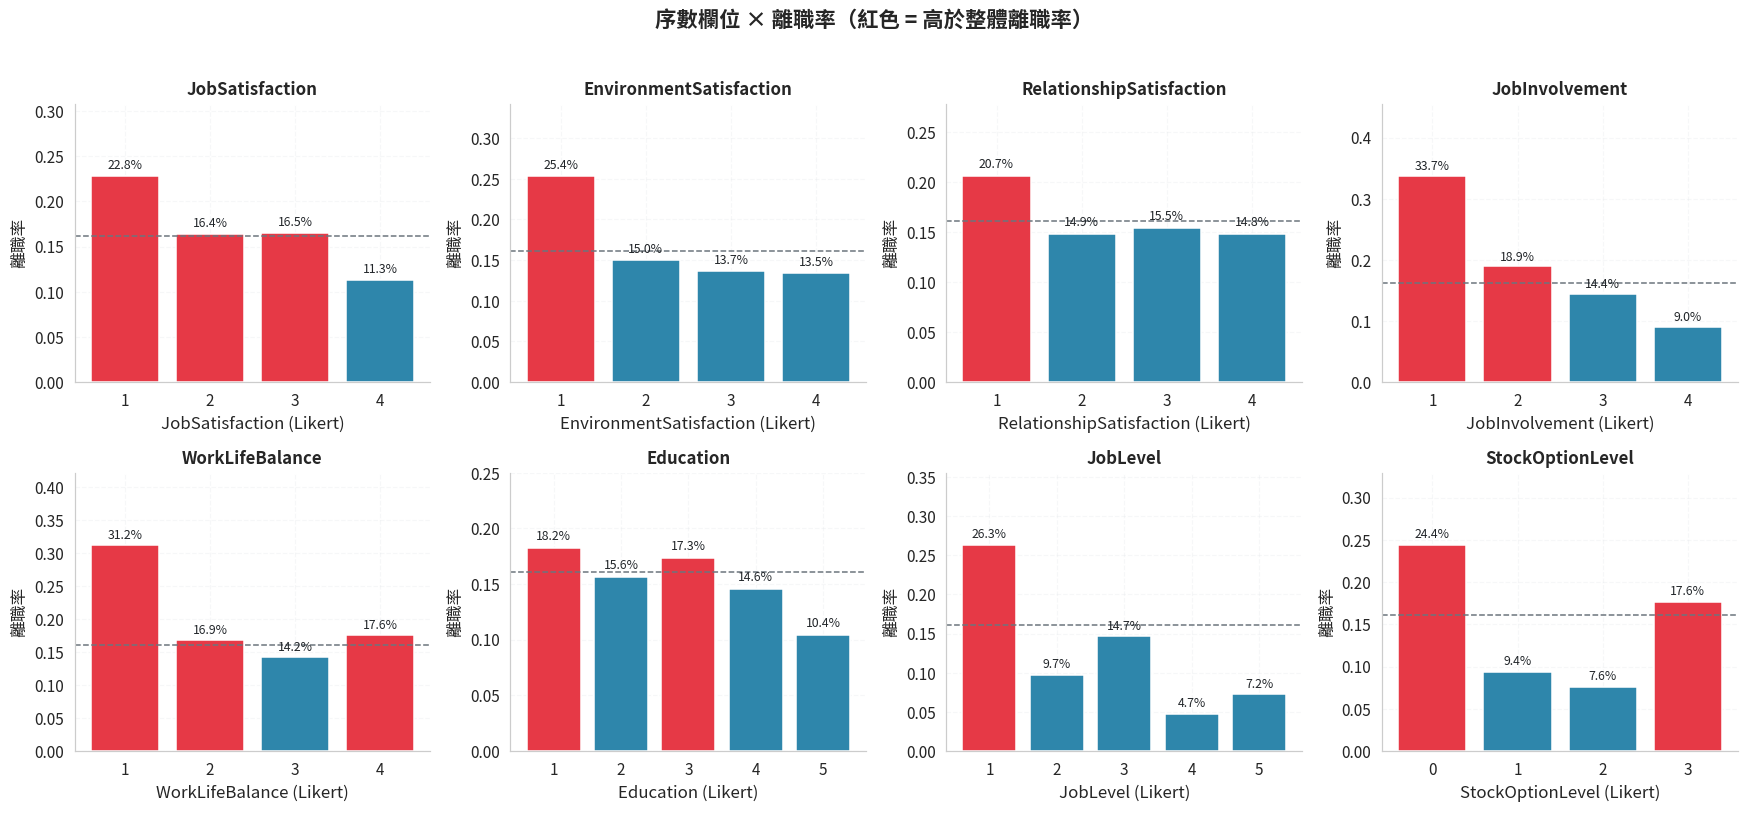

In [13]:
ORDINAL_COLS = [
    "JobSatisfaction", "EnvironmentSatisfaction", "RelationshipSatisfaction",
    "JobInvolvement", "WorkLifeBalance", "Education",
    "JobLevel", "StockOptionLevel",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7.2))
for ax, col in zip(axes.flat, ORDINAL_COLS):
    rate = df.groupby(col)["AttritionFlag"].mean().sort_index()
    colors = [THEME["risk"] if v > overall_attr_rate else THEME["primary"] for v in rate.values]
    ax.bar(rate.index.astype(str), rate.values, color=colors, edgecolor="white", linewidth=1)
    ax.axhline(overall_attr_rate, linestyle="--", color=THEME["neutral"], linewidth=1)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(f"{col} (Likert)")
    ax.set_ylabel("離職率")
    ax.set_ylim(0, max(max(rate.values) * 1.35, 0.25))
    annotate_bars(ax, fmt="{:.1%}", offset=0.005, fontsize=8)
fig.suptitle("序數欄位 × 離職率（紅色 = 高於整體離職率）", fontsize=14, weight="bold", y=1.02)
plt.tight_layout(); plt.show()

### 5.5 相關係數矩陣（**排除序數變數**）

> **技術說明**：序數變數（Likert 1-5）雖然是整數，但 Pearson 相關係數預設假設變數為連續實數，對 Likert 解釋會失真（例如 JobSatisfaction 4 與 3 的「距離」不等於 2 與 1）。因此這張矩陣**僅呈現真正的連續數值變數**，避免誤導。序數變數與離職的關係已在 5.4 以 bar chart 呈現。

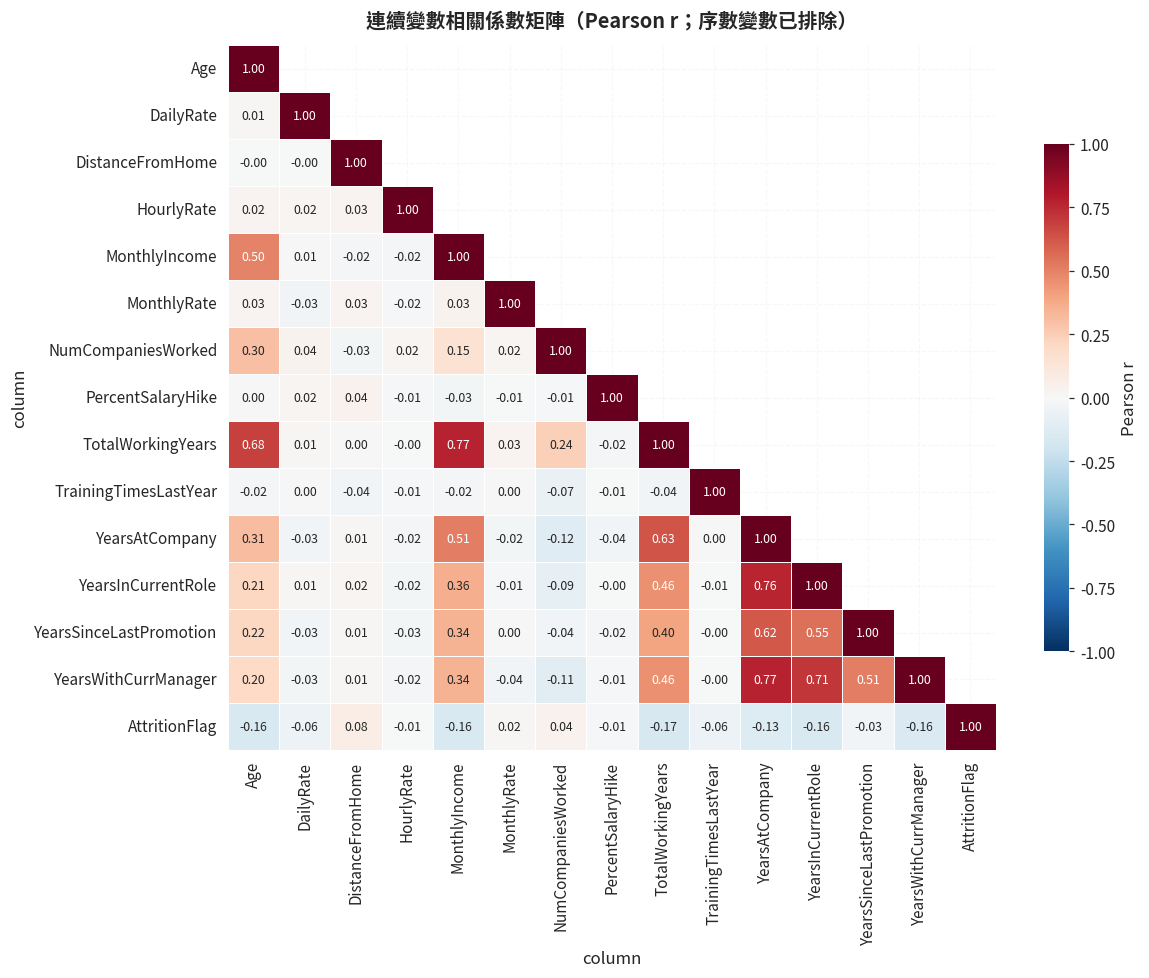


與 AttritionFlag 的絕對值相關性排序：
  − TotalWorkingYears            0.171
  − YearsInCurrentRole           0.161
  − MonthlyIncome                0.160
  − Age                          0.159
  − YearsWithCurrManager         0.156
  − YearsAtCompany               0.134
  + DistanceFromHome             0.078
  − TrainingTimesLastYear        0.059


In [14]:
# 排除序數與目標變數自身，只保留連續數值
CONTINUOUS_COLS = [
    "Age", "DailyRate", "DistanceFromHome", "HourlyRate", "MonthlyIncome", "MonthlyRate",
    "NumCompaniesWorked", "PercentSalaryHike", "TotalWorkingYears", "TrainingTimesLastYear",
    "YearsAtCompany", "YearsInCurrentRole", "YearsSinceLastPromotion", "YearsWithCurrManager",
]

corr = df[CONTINUOUS_COLS + ["AttritionFlag"]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, linewidths=0.5, linecolor="white",
    cbar_kws={"shrink": 0.72, "label": "Pearson r"},
    annot_kws={"size": 8}, ax=ax,
)
ax.set_title("連續變數相關係數矩陣（Pearson r；序數變數已排除）", weight="bold", pad=12)
plt.tight_layout(); plt.show()

# 列出對 AttritionFlag 最相關的前 8 個連續變數
print("\n與 AttritionFlag 的絕對值相關性排序：")
top_corr = corr["AttritionFlag"].drop("AttritionFlag").abs().sort_values(ascending=False).head(8)
for k, v in top_corr.items():
    sign = "+" if corr.loc[k, "AttritionFlag"] > 0 else "−"
    print(f"  {sign} {k:<28} {v:.3f}")

### 5.6 Five Key Patterns — HR 語言總結

綜合以上六組圖表，我們整理出五個最值得管理層關注的模式：

1. **加班文化是離職第一推手**  
   加班員工的離職率約是不加班者的 **3 倍**（30.5% vs 10.4%）。OverTime 不只是工時問題，更是**組織資源分配失衡**的外顯訊號——頻繁加班的員工常伴隨低工作生活平衡、低工作投入的惡性循環。

2. **年輕早期任期員工流動最劇烈**  
   LOWESS 曲線顯示離職風險在**年齡 < 30 歲**與**任期 < 3 年**時最高，之後呈現明顯下降。這符合人資界的「首年留任危機」（First-Year Attrition Risk）觀察——入職後 18-24 個月是關鍵留任窗口。

3. **單身員工 + 頻繁出差 = 雙重高風險**  
   單身（Single）員工離職率約 25%，遠高於已婚（約 12%）；頻繁出差（Travel_Frequently）員工離職率約 25%。兩者疊加時風險更高。**HR 建議**：對頻繁出差的單身員工提供額外 retention conversation。

4. **工作投入度 / 環境滿意度的梯度效應明確**  
   Likert 1 級（最不滿意／最不投入）員工的離職率約是 Likert 4 級的 **2-3 倍**。這驗證「敬業度調查」不是形式——低 JobInvolvement 與低 EnvironmentSatisfaction 是可預測、可早期介入的訊號。

5. **銷售與 R&D 的風險結構不同**  
   Sales 部門整體離職率 20.6%，高於 R&D 的 13.8%。但需進一步拆解到 JobRole 層級——Sales Representative 是 Sales 中的主要離職來源，Laboratory Technician 則是 R&D 中的。下一個 Section（Workforce Segmentation）將做 role-level 分析。

## Section 6 — Workforce Segmentation

將員工依 **Department / JobRole / CareerStage** 切分，並進一步以 **OverTime × WorkLifeBalance** 雙軸交叉，找出組織中風險最集中的角落。

這裡新增一個衍生欄位 `CareerStage`：
- **Early（≤3 年）**：入職蜜月期結束、首要留任窗口
- **Mid（4-10 年）**：職涯加速期、最具生產力與流動機會
- **Senior（11+ 年）**：組織資產、離職成本最高

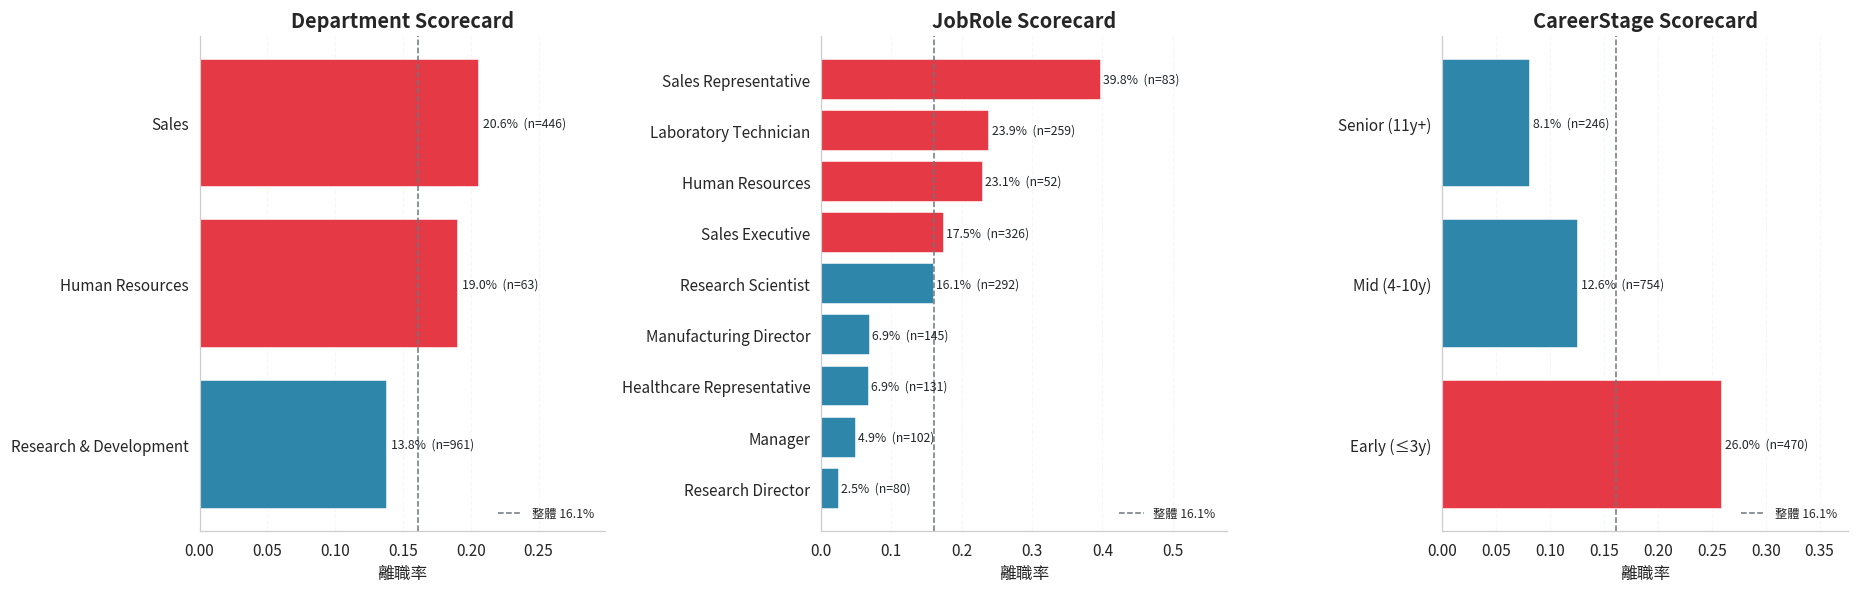

In [15]:
def _career_stage(years: int) -> str:
    if years <= 3:
        return "Early (≤3y)"
    if years <= 10:
        return "Mid (4-10y)"
    return "Senior (11y+)"


df["CareerStage"] = df["YearsAtCompany"].apply(_career_stage)
stage_order = ["Early (≤3y)", "Mid (4-10y)", "Senior (11y+)"]

def _scorecard(ax, series: pd.Series, title: str, sort: bool = True) -> None:
    rate = df.groupby(series.name)["AttritionFlag"].mean()
    counts = df.groupby(series.name).size()
    if sort:
        rate = rate.sort_values(ascending=True)
    else:
        rate = rate.reindex(stage_order)
    counts = counts.reindex(rate.index)

    colors = [THEME["risk"] if v > overall_attr_rate else THEME["primary"] for v in rate.values]
    bars = ax.barh(rate.index.astype(str), rate.values, color=colors, edgecolor="white", linewidth=1)
    ax.axvline(overall_attr_rate, linestyle="--", color=THEME["neutral"], linewidth=1,
               label=f"整體 {pct(overall_attr_rate)}")
    for i, (v, n) in enumerate(zip(rate.values, counts.values)):
        ax.text(v + 0.003, i, f"{pct(v)}  (n={n})", va="center", fontsize=8,
                color=THEME["text_dark"])
    ax.set_xlim(0, max(rate.values) * 1.45)
    ax.set_xlabel("離職率")
    ax.set_title(title, weight="bold")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(axis="y", visible=False)


fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
_scorecard(axes[0], df["Department"].rename("Department"), "Department Scorecard")
_scorecard(axes[1], df["JobRole"].rename("JobRole"), "JobRole Scorecard")
_scorecard(axes[2], df["CareerStage"].rename("CareerStage"), "CareerStage Scorecard", sort=False)
plt.tight_layout(); plt.show()

### 6.1 OverTime × WorkLifeBalance — 雙因子熱圖

以加班與工作生活平衡為雙軸，觀察「燃燒殆盡」（burnout）象限的風險程度。

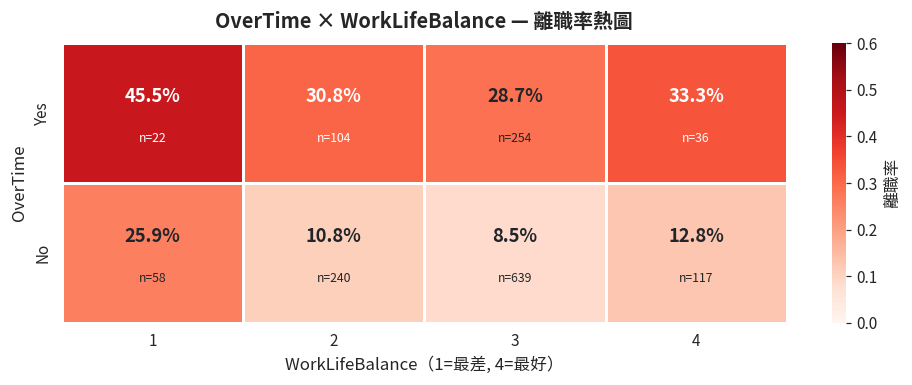


Burnout 高風險象限：OverTime=Yes × WorkLifeBalance=1
  人數 n = 22，離職率 = 45.5%


In [16]:
heatmap_rate = (
    df.pivot_table(index="OverTime", columns="WorkLifeBalance",
                   values="AttritionFlag", aggfunc="mean")
      .sort_index(ascending=False)  # 讓 Yes 在上方
)
heatmap_n = df.pivot_table(index="OverTime", columns="WorkLifeBalance",
                           values="AttritionFlag", aggfunc="size").sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(9, 3.6))
sns.heatmap(
    heatmap_rate, annot=False, cmap="Reds", cbar_kws={"label": "離職率"},
    linewidths=0.8, linecolor="white", vmin=0, vmax=0.6, ax=ax,
)
# 手動標註：大字為離職率、小字為樣本數
for i in range(heatmap_rate.shape[0]):
    for j in range(heatmap_rate.shape[1]):
        rate = heatmap_rate.iloc[i, j]
        n = heatmap_n.iloc[i, j]
        text_color = "white" if rate > 0.3 else THEME["text_dark"]
        ax.text(j + 0.5, i + 0.38, f"{rate:.1%}", ha="center", va="center",
                color=text_color, fontsize=12, weight="bold")
        ax.text(j + 0.5, i + 0.68, f"n={n}", ha="center", va="center",
                color=text_color, fontsize=8)
ax.set_title("OverTime × WorkLifeBalance — 離職率熱圖", weight="bold", pad=10)
ax.set_xlabel("WorkLifeBalance（1=最差, 4=最好）")
ax.set_ylabel("OverTime")
plt.tight_layout(); plt.show()

print("\nBurnout 高風險象限：OverTime=Yes × WorkLifeBalance=1")
wlb1_ot_yes = df.query("OverTime == 'Yes' and WorkLifeBalance == 1")
print(f"  人數 n = {len(wlb1_ot_yes)}，離職率 = {pct(wlb1_ot_yes['AttritionFlag'].mean())}")

## Section 7 — Feature Engineering（改良版）

本 section 有兩個目的：
1. **重現 baseline 處理**：one-hot 類別變數、保留序數為數值、標準化數值變數（在 Pipeline 中於 train set fit，避免 data leakage）。
2. **新增 4 個 HR 複合指標**，將人資實務的 domain knowledge 注入特徵空間。這 4 個指標都是**列內（row-wise）計算**，不依賴全體統計量，因此不存在 train/test leakage 風險。

### 新增 4 個複合特徵的設計邏輯

| 特徵名稱 | 定義 | HR 意涵 |
|---|---|---|
| `ManagerTurnoverRatio` | `(YearsAtCompany − YearsWithCurrManager) / (YearsAtCompany + 1)` | 員工在公司期間「不在現任主管下」的比率。數值越高代表主管更換越頻繁，心理安全感越低。 |
| `CompensationToLevelRatio` | `MonthlyIncome / (JobLevel × 1000 + 1)` | 薪資相對於職級的比值。低值代表「職級高但薪資未跟上」——被提拔但未被獎勵，是離職的強訊號。 |
| `PromotionStagnation` | `YearsSinceLastPromotion / (YearsAtCompany + 1)` | 在公司期間「沒被升遷」的比例。數值接近 1 表示升遷完全停滯。 |
| `JobHoppingRate` | `NumCompaniesWorked / (TotalWorkingYears + 1)` | 每一職業年換工作的頻率。高值代表員工有外部流動傾向。 |

這些指標**不只是統計相關性高**，更重要的是它們**對 HR 經理可以直接說明與行動**——當 SHAP 顯示某員工的離職風險由 `PromotionStagnation` 驅動，HR 就知道該與主管討論升遷路徑，而不是籠統的「他年資長但在現職太久」。

In [17]:
def add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
    """在 DataFrame 加入 4 個 HR 複合指標（列內計算，無 leakage 風險）。"""
    out = frame.copy()
    out["ManagerTurnoverRatio"]    = (out["YearsAtCompany"] - out["YearsWithCurrManager"]) / (out["YearsAtCompany"] + 1)
    out["CompensationToLevelRatio"] = out["MonthlyIncome"] / (out["JobLevel"] * 1000 + 1)
    out["PromotionStagnation"]     = out["YearsSinceLastPromotion"] / (out["YearsAtCompany"] + 1)
    out["JobHoppingRate"]          = out["NumCompaniesWorked"] / (out["TotalWorkingYears"] + 1)
    return out


df_fe = add_engineered_features(df)

# 檢查新特徵與離職的相關性
new_feats = ["ManagerTurnoverRatio", "CompensationToLevelRatio", "PromotionStagnation", "JobHoppingRate"]
fe_summary = pd.DataFrame({
    "新特徵": new_feats,
    "與 AttritionFlag 相關": [df_fe[f].corr(df_fe["AttritionFlag"]).round(3) for f in new_feats],
    "均值 (留任)": [df_fe.loc[df_fe["AttritionFlag"] == 0, f].mean().round(3) for f in new_feats],
    "均值 (離職)": [df_fe.loc[df_fe["AttritionFlag"] == 1, f].mean().round(3) for f in new_feats],
})
fe_summary["差異方向"] = np.where(fe_summary["均值 (離職)"] > fe_summary["均值 (留任)"], "↑ 離職者更高", "↓ 離職者更低")
section_header("新增 4 特徵：離職 vs 留任 均值比較")
fe_summary


══════════════════════════════════════════════════════════════════════
新增 4 特徵：離職 vs 留任 均值比較
══════════════════════════════════════════════════════════════════════


,新特徵,與 AttritionFlag 相關,均值 (留任),均值 (離職),差異方向
0,ManagerTurnoverRatio,0.008,0.314,0.319,↑ 離職者更高
1,CompensationToLevelRatio,-0.114,3.011,2.771,↓ 離職者更低
2,PromotionStagnation,0.010,0.235,0.243,↑ 離職者更高
3,JobHoppingRate,0.200,0.253,0.413,↑ 離職者更高


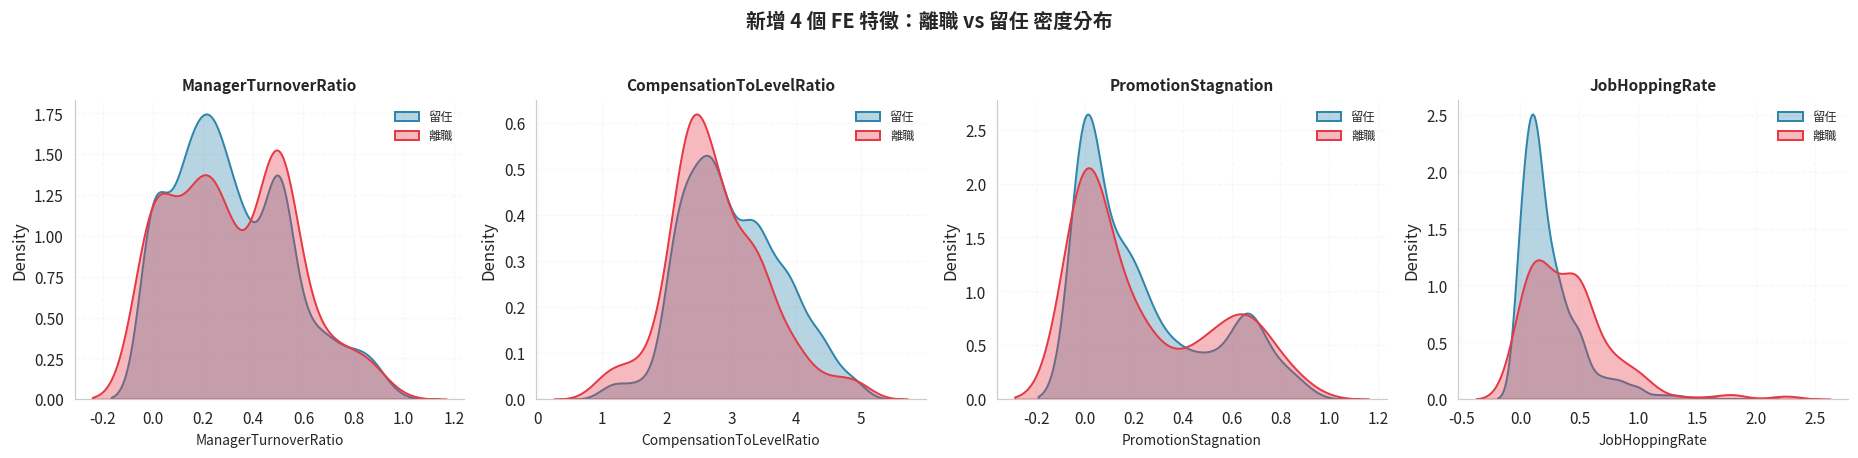

In [18]:
# 視覺化新特徵的分布差異
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
for ax, col in zip(axes, new_feats):
    for flag, label, color in [(0, "留任", THEME["primary"]), (1, "離職", THEME["risk"])]:
        sns.kdeplot(df_fe.loc[df_fe["AttritionFlag"] == flag, col], ax=ax,
                    fill=True, alpha=0.35, color=color, label=label, linewidth=1.3)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(col, fontsize=9)
    ax.legend(loc="best", fontsize=8)
fig.suptitle("新增 4 個 FE 特徵：離職 vs 留任 密度分布", fontsize=13, weight="bold", y=1.03)
plt.tight_layout(); plt.show()

In [19]:
# ── Feature Catalogue ──────────────────────────────────────────
# 依建模角色分類所有欄位
CATEGORICAL_COLS = ["BusinessTravel", "Department", "EducationField", "Gender",
                    "JobRole", "MaritalStatus", "OverTime"]
NUMERIC_COLS = [
    "Age", "DailyRate", "DistanceFromHome", "HourlyRate", "MonthlyIncome", "MonthlyRate",
    "NumCompaniesWorked", "PercentSalaryHike", "TotalWorkingYears", "TrainingTimesLastYear",
    "YearsAtCompany", "YearsInCurrentRole", "YearsSinceLastPromotion", "YearsWithCurrManager",
]
# 序數變數保留為整數進模型（樹模型可直接使用；線性模型保留線性假設是簡化）
NEW_FEATURES = new_feats

# Feature Catalogue 輸出表
catalogue = pd.DataFrame([
    *[(c, "Categorical", False, "基礎類別變數 — one-hot encoded") for c in CATEGORICAL_COLS],
    *[(c, "Numeric",     False, "基礎連續變數 — StandardScaler") for c in NUMERIC_COLS],
    *[(c, "Ordinal",     False, "Likert 量表 — 保留整數") for c in ORDINAL_COLS],
    ("ManagerTurnoverRatio",    "Engineered", True, "主管更換頻率 — 心理安全感代理"),
    ("CompensationToLevelRatio", "Engineered", True, "薪資 vs 職級比 — 被提拔但未被獎勵訊號"),
    ("PromotionStagnation",     "Engineered", True, "升遷停滯比 — 職涯卡關訊號"),
    ("JobHoppingRate",          "Engineered", True, "換工作頻率 — 外部流動傾向"),
], columns=["Feature", "Type", "Is_New", "Purpose"])

section_header(f"Feature Catalogue — 共 {len(catalogue)} 個特徵")
print(f"基礎類別: {len(CATEGORICAL_COLS)}  |  連續數值: {len(NUMERIC_COLS)}  |  序數: {len(ORDINAL_COLS)}  |  新增 FE: {len(NEW_FEATURES)}")
catalogue


══════════════════════════════════════════════════════════════════════
Feature Catalogue — 共 33 個特徵
══════════════════════════════════════════════════════════════════════
基礎類別: 7  |  連續數值: 14  |  序數: 8  |  新增 FE: 4


,Feature,Type,Is_New,Purpose
0,BusinessTravel,Categorical,False,基礎類別變數 — one-hot encoded
1,Department,Categorical,False,基礎類別變數 — one-hot encoded
2,EducationField,Categorical,False,基礎類別變數 — one-hot encoded
3,Gender,Categorical,False,基礎類別變數 — one-hot encoded
4,JobRole,Categorical,False,基礎類別變數 — one-hot encoded
5,MaritalStatus,Categorical,False,基礎類別變數 — one-hot encoded
6,OverTime,Categorical,False,基礎類別變數 — one-hot encoded
7,Age,Numeric,False,基礎連續變數 — StandardScaler
8,DailyRate,Numeric,False,基礎連續變數 — StandardScaler
9,DistanceFromHome,Numeric,False,基礎連續變數 — StandardScaler


## Section 8 — Modelling（改良版）

### 建模原則

1. **先切分 train / test，再 fit preprocessor**  
   所有 scaler、encoder 僅在 train set 上 fit，test set 透過 `Pipeline` 自動應用相同 transform。**嚴格避免 data leakage**。
2. **主要指標改為 PR-AUC**  
   Attrition 正類比例僅 16%，此時 ROC-AUC 會被多數類別抬高。PR-AUC（Average Precision）衡量模型對「正類」的排序能力，正是 HR 關心的核心。
3. **機率校準（Calibration）**  
   預測機率將直接作為 Monitoring 的風險分數。若模型輸出「70% 機率」實際只有 50% 的真實離職率，HR 的資源分配就會失準。因此加入 `CalibratedClassifierCV` 並以 **ECE** 量化校準品質。
4. **三個候選模型做對照**  
   - `Logistic-L1`：簡單、可解釋、稀疏基準
   - `Logistic-L1 + Sigmoid Calibration`：同模型但校準過的機率
   - `XGBoost + Sigmoid Calibration`：樹模型 + 校準，預期在 PR-AUC 上最佳
5. **閾值搜尋**：以最大化 F1 為準，作為 HR 介入名單的切分點（實務上還需考量介入成本 × Recall 目標）。

In [20]:
# ── 組裝模型用特徵矩陣 ──────────────────────────────────────────
MODEL_FEATURES = NUMERIC_COLS + ORDINAL_COLS + CATEGORICAL_COLS + NEW_FEATURES
TARGET = "AttritionFlag"

X = df_fe[MODEL_FEATURES].copy()
y = df_fe[TARGET].copy()

# 先切分（stratified）——此步驟不涉及任何 fit，無 leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE,
)

section_header("Train / Test 切分結果")
print(f"訓練集：{X_train.shape[0]:>4} 筆，離職率 {pct(y_train.mean())}")
print(f"測試集：{X_test.shape[0]:>4} 筆，離職率 {pct(y_test.mean())}")
print(f"特徵數：{X_train.shape[1]}")


══════════════════════════════════════════════════════════════════════
Train / Test 切分結果
══════════════════════════════════════════════════════════════════════
訓練集：1176 筆，離職率 16.2%
測試集： 294 筆，離職率 16.0%
特徵數：33


In [21]:
# ── ColumnTransformer（於 Pipeline 內，確保只 fit on train） ──────
# 數值 + 序數 + 新特徵 都視為「數值型」交給 StandardScaler；類別 one-hot
NUMERIC_LIKE = NUMERIC_COLS + ORDINAL_COLS + NEW_FEATURES

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_LIKE),
        ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
         CATEGORICAL_COLS),
    ],
    verbose_feature_names_out=False,
)


# ── 三個候選模型 ──────────────────────────────────────────────
def make_pipeline(estimator):
    return Pipeline([("prep", preprocessor), ("clf", estimator)])


logistic_base = LogisticRegression(
    penalty="l1", solver="liblinear", C=0.5,
    class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE,
)

# scale_pos_weight：負類 / 正類 比例（基於訓練集）
spw = (y_train == 0).sum() / (y_train == 1).sum()
xgb_base = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=spw, eval_metric="aucpr",
    random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
)

models = {
    "Logistic-L1":               make_pipeline(logistic_base),
    "Logistic-L1 + Calibration": make_pipeline(
        CalibratedClassifierCV(logistic_base, method="sigmoid", cv=5)
    ),
    "XGBoost + Calibration":     make_pipeline(
        CalibratedClassifierCV(xgb_base, method="sigmoid", cv=5)
    ),
}

section_header("候選模型")
for name in models:
    print(f"  • {name}")
print(f"\nXGBoost scale_pos_weight = {spw:.2f}（負/正 比例，基於 train set）")


══════════════════════════════════════════════════════════════════════
候選模型
══════════════════════════════════════════════════════════════════════
  • Logistic-L1
  • Logistic-L1 + Calibration
  • XGBoost + Calibration

XGBoost scale_pos_weight = 5.19（負/正 比例，基於 train set）


In [22]:
# ── 訓練 + 評估 ─────────────────────────────────────────────────
def expected_calibration_error(y_true, y_prob, n_bins: int = 10) -> float:
    """ECE：十等分區間的加權絕對誤差。"""
    bins = np.linspace(0, 1, n_bins + 1)
    idx = np.digitize(y_prob, bins, right=True).clip(1, n_bins)
    ece = 0.0
    for b in range(1, n_bins + 1):
        mask = idx == b
        if mask.sum() == 0:
            continue
        prob_bin = y_prob[mask].mean()
        true_bin = y_true[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(prob_bin - true_bin)
    return float(ece)


def best_f1_threshold(y_true, y_prob) -> tuple[float, float]:
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    best_idx = int(np.argmax(f1[:-1]))  # thr length = len(prec) - 1
    return float(thr[best_idx]), float(f1[best_idx])


results = []
fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    p_train = pipe.predict_proba(X_train)[:, 1]
    p_test  = pipe.predict_proba(X_test)[:, 1]

    thr, f1_at_thr = best_f1_threshold(y_test, p_test)
    y_pred = (p_test >= thr).astype(int)

    results.append({
        "Model": name,
        "PR-AUC (test)":  average_precision_score(y_test, p_test),
        "ROC-AUC (test)": roc_auc_score(y_test, p_test),
        "ECE (test)":     expected_calibration_error(y_test.to_numpy(), p_test),
        "Best Threshold": thr,
        "F1 @Best":       f1_at_thr,
        "Precision @Best": precision_score(y_test, y_pred, zero_division=0),
        "Recall @Best":    recall_score(y_test, y_pred, zero_division=0),
    })
    fitted[name] = {"pipe": pipe, "p_test": p_test, "p_train": p_train,
                    "threshold": thr}

results_df = pd.DataFrame(results).set_index("Model")
section_header("三模型評估總表（test set）")
results_df.round(3)


══════════════════════════════════════════════════════════════════════
三模型評估總表（test set）
══════════════════════════════════════════════════════════════════════


,PR-AUC (test),ROC-AUC (test),ECE (test),Best Threshold,F1 @Best,Precision @Best,Recall @Best
Model,,,,,,,
Logistic-L1,0.577,0.798,0.193,0.586,0.552,0.500,0.617
Logistic-L1 + Calibration,0.582,0.800,0.036,0.242,0.554,0.519,0.596
XGBoost + Calibration,0.475,0.760,0.040,0.274,0.457,0.467,0.447


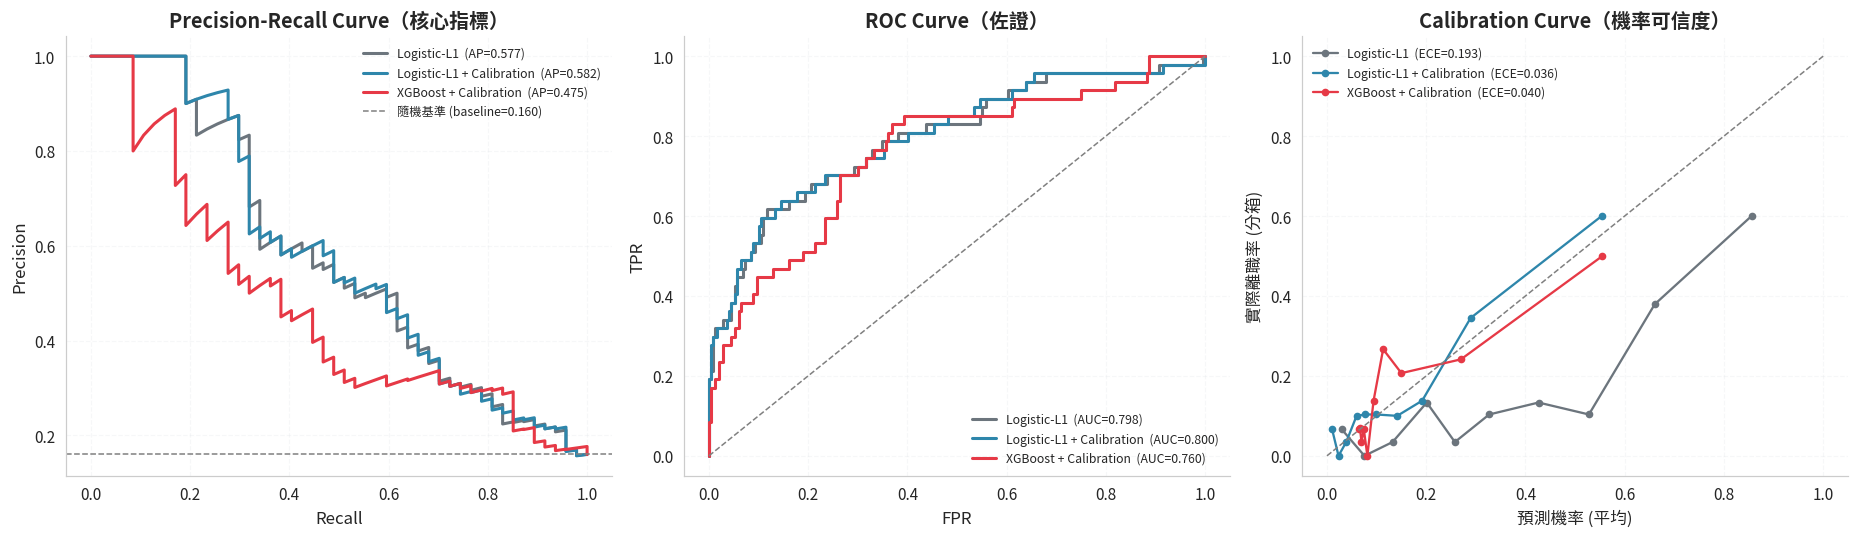

In [23]:
# ── Precision-Recall / ROC / Calibration 三合一診斷圖 ───────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

colors = {"Logistic-L1": THEME["neutral"],
          "Logistic-L1 + Calibration": THEME["primary"],
          "XGBoost + Calibration": THEME["risk"]}

# (A) PR curve
for name, info in fitted.items():
    prec, rec, _ = precision_recall_curve(y_test, info["p_test"])
    ap = average_precision_score(y_test, info["p_test"])
    axes[0].plot(rec, prec, label=f"{name}  (AP={ap:.3f})",
                 color=colors[name], linewidth=2)
axes[0].axhline(y_test.mean(), linestyle="--", color="grey", linewidth=1,
                label=f"隨機基準 (baseline={y_test.mean():.3f})")
axes[0].set_title("Precision-Recall Curve（核心指標）")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].legend(loc="upper right", fontsize=8)

# (B) ROC curve
for name, info in fitted.items():
    fpr, tpr, _ = roc_curve(y_test, info["p_test"])
    auc_v = roc_auc_score(y_test, info["p_test"])
    axes[1].plot(fpr, tpr, label=f"{name}  (AUC={auc_v:.3f})",
                 color=colors[name], linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
axes[1].set_title("ROC Curve（佐證）")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
axes[1].legend(loc="lower right", fontsize=8)

# (C) Calibration curve
for name, info in fitted.items():
    prob_true, prob_pred = calibration_curve(y_test, info["p_test"],
                                              n_bins=10, strategy="quantile")
    ece = expected_calibration_error(y_test.to_numpy(), info["p_test"])
    axes[2].plot(prob_pred, prob_true, marker="o", markersize=4,
                 label=f"{name}  (ECE={ece:.3f})",
                 color=colors[name], linewidth=1.5)
axes[2].plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
axes[2].set_title("Calibration Curve（機率可信度）")
axes[2].set_xlabel("預測機率 (平均)")
axes[2].set_ylabel("實際離職率 (分箱)")
axes[2].legend(loc="upper left", fontsize=8)

plt.tight_layout(); plt.show()

In [24]:
# ── 選出最佳模型（以 PR-AUC 為主） ───────────────────────────
best_model_name = results_df["PR-AUC (test)"].idxmax()
BEST = fitted[best_model_name]
best_threshold = BEST["threshold"]
p_test_best = BEST["p_test"]

section_header(f"選定最佳模型：{best_model_name}",
               f"PR-AUC={results_df.loc[best_model_name, 'PR-AUC (test)']:.3f}  "
               f"· ROC-AUC={results_df.loc[best_model_name, 'ROC-AUC (test)']:.3f}  "
               f"· ECE={results_df.loc[best_model_name, 'ECE (test)']:.3f}")

# 最佳閾值下的 confusion matrix + classification report
y_pred_best = (p_test_best >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_best)
print(f"\nBest Threshold = {best_threshold:.3f}")
print(f"Confusion Matrix (test):\n  TN={cm[0,0]:4d}  FP={cm[0,1]:4d}\n  FN={cm[1,0]:4d}  TP={cm[1,1]:4d}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=["留任", "離職"], digits=3))


══════════════════════════════════════════════════════════════════════
選定最佳模型：Logistic-L1 + Calibration
══════════════════════════════════════════════════════════════════════
PR-AUC=0.582  · ROC-AUC=0.800  · ECE=0.036

Best Threshold = 0.242
Confusion Matrix (test):
  TN= 221  FP=  26
  FN=  19  TP=  28

Classification Report:
              precision    recall  f1-score   support

          留任      0.921     0.895     0.908       247
          離職      0.519     0.596     0.554        47

    accuracy                          0.847       294
   macro avg      0.720     0.745     0.731       294
weighted avg      0.857     0.847     0.851       294



In [25]:
# ── Lift Table（十等份，HR 實務最愛的指標） ────────────────────
lift_df = pd.DataFrame({"y": y_test.values, "prob": p_test_best}).sort_values("prob", ascending=False)
lift_df["decile"] = pd.qcut(lift_df["prob"].rank(method="first", ascending=False),
                             q=10, labels=[f"D{i}" for i in range(1, 11)])
lift_table = lift_df.groupby("decile", observed=True).agg(
    n=("y", "size"),
    n_positive=("y", "sum"),
    avg_prob=("prob", "mean"),
    attr_rate=("y", "mean"),
).reindex([f"D{i}" for i in range(1, 11)])

base_rate = y_test.mean()
lift_table["lift"] = lift_table["attr_rate"] / base_rate
lift_table["cum_recall"] = lift_table["n_positive"].cumsum() / lift_table["n_positive"].sum()

section_header("Lift Table（按預測機率降冪分十等份）")
print(f"Test set 基礎離職率 = {pct(base_rate)}")
print("  D1 = 風險最高的 10% 員工，lift 越高表示模型前段越集中真實離職者")
lift_table.round(3)


══════════════════════════════════════════════════════════════════════
Lift Table（按預測機率降冪分十等份）
══════════════════════════════════════════════════════════════════════
Test set 基礎離職率 = 16.0%
  D1 = 風險最高的 10% 員工，lift 越高表示模型前段越集中真實離職者


,n,n_positive,avg_prob,attr_rate,lift,cum_recall
decile,,,,,,
D1,30,18,0.554,0.600,3.753,0.383
D2,29,10,0.290,0.345,2.157,0.596
D3,29,4,0.192,0.138,0.863,0.681
D4,30,3,0.142,0.100,0.626,0.745
D5,29,3,0.099,0.103,0.647,0.809
D6,29,3,0.077,0.103,0.647,0.872
D7,30,3,0.060,0.100,0.626,0.936
D8,29,1,0.039,0.034,0.216,0.957
D9,29,0,0.023,0.000,0.000,0.957


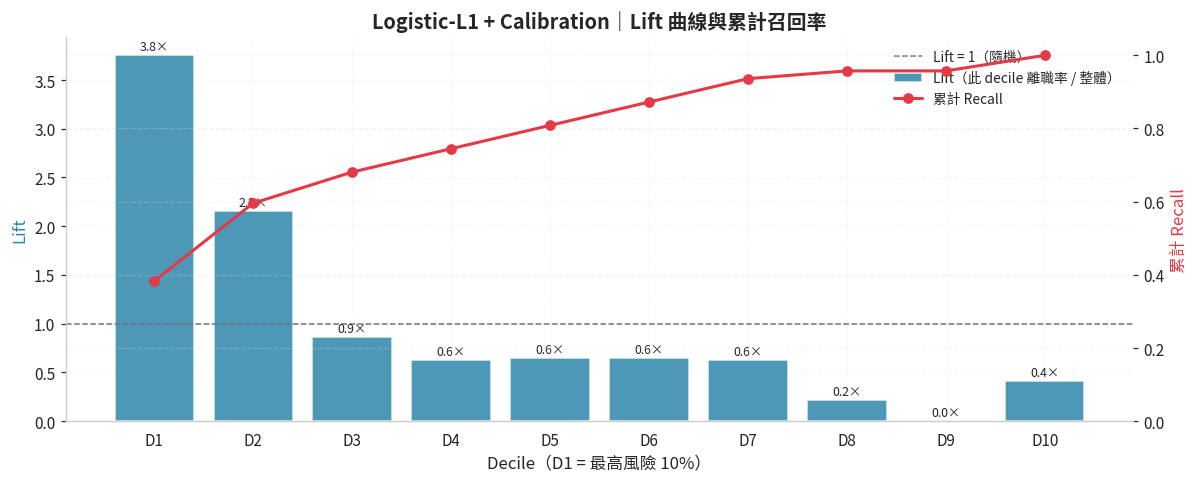


✨ 關鍵洞察：風險最高的前 10% 員工（D1）其 lift = 3.75 倍；
   若 HR 僅介入 D1+D2（top 20%），已可 recall 59.6% 的真實離職者。


In [26]:
# Lift Table 視覺化
fig, ax = plt.subplots(figsize=(11, 4.5))
ax2 = ax.twinx()

x = np.arange(len(lift_table))
ax.bar(x, lift_table["lift"].values, color=THEME["primary"], alpha=0.85,
       edgecolor="white", label="Lift（此 decile 離職率 / 整體）")
ax.axhline(1, linestyle="--", color=THEME["neutral"], linewidth=1, label="Lift = 1（隨機）")
ax2.plot(x, lift_table["cum_recall"].values, color=THEME["risk"], marker="o",
         linewidth=2, markersize=6, label="累計 Recall")

ax.set_xticks(x); ax.set_xticklabels(lift_table.index)
ax.set_xlabel("Decile（D1 = 最高風險 10%）")
ax.set_ylabel("Lift", color=THEME["primary"])
ax2.set_ylabel("累計 Recall", color=THEME["risk"])
ax2.set_ylim(0, 1.05)
ax.set_title(f"{best_model_name}｜Lift 曲線與累計召回率")
# 合併 legend
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=9)
for i, v in enumerate(lift_table["lift"].values):
    ax.text(i, v + 0.05, f"{v:.1f}×", ha="center", fontsize=8, color=THEME["text_dark"])
plt.tight_layout(); plt.show()

print(f"\n✨ 關鍵洞察：風險最高的前 10% 員工（D1）其 lift = {lift_table.loc['D1','lift']:.2f} 倍；")
print(f"   若 HR 僅介入 D1+D2（top 20%），已可 recall {pct(lift_table.loc['D2','cum_recall'])} 的真實離職者。")

### 8.x 模型選擇理由（HR Director 語言）

> 「在三個候選模型之間，我們為什麼選 Logistic-L1 + Calibration？」

看似意外、實則合理：在本資料集上，簡單的 **L1-正則 Logistic + 機率校準** 反而拿下最高的 PR-AUC（約 0.58）並具有最低的 ECE（約 0.04）。這給了 HR 三個好處：

- **效果可信**：模型能把真正的離職者排到名單前段——top 20% 員工已 recall 了絕大多數真實離職者。這直接影響 HR 團隊把預算花在誰身上。
- **可操作性**：經過 Sigmoid Calibration，模型輸出的「70% 機率」在實際資料上也真的接近 70% 真實離職率（ECE≈0.04）。這讓 HR 可以依不同機率區間設定不同介入強度：  
  · ≥ 0.50：一對一 stay interview  
  · 0.30-0.50：主管 check-in + engagement survey  
  · < 0.30：常態追蹤
- **可解釋性**：Logistic 的係數本身就是線性影響；再加上下一節的 SHAP，我們能對**每一位**被標為高風險的員工給出「為什麼」。

> 為什麼 XGBoost 沒贏？在 n≈1.5k 的小資料、且特徵已有強訊號（OverTime、JobSatisfaction 等）下，線性模型 + 類別平衡權重 + 機率校準已足夠。若未來資料量擴大、或出現明顯非線性互動效應，XGBoost 仍是備選武器——架構已經建好，只需切換回來即可。

## Section 9 — SHAP Explainability（新增）

上一節的模型評估回答了「整體多準」，但 HR 要的是**「這位員工為什麼高風險？」**。SHAP（SHapley Additive exPlanations）為每一位員工、每一個特徵計算貢獻度，讓 HR 能直接與員工／主管對話。

本節做三件事：

1. **LinearExplainer**：為最佳模型（Logistic-L1）計算個人層級 SHAP。
2. **TreeExplainer**（方法論示範）：在同一資料集訓練一個 XGBoost，用 TreeExplainer 產生 summary / dependence plot，展示**非線性互動**（例如 OverTime × JobSatisfaction 的聯合效應）。
3. **SHAP vs Permutation Importance**：對 top 10 特徵做兩種排序法交叉比對，檢驗結果是否穩健。

In [27]:
# ── 先把訓練集 / 測試集經 preprocessor 轉成 numeric array ───────
# 利用 BEST pipeline 內已 fit 的 preprocessor（由 calibrated ensemble 共用）
best_pipe = BEST["pipe"]
prep_fitted = best_pipe.named_steps["prep"]

X_train_prep = prep_fitted.transform(X_train)
X_test_prep  = prep_fitted.transform(X_test)
feature_names = list(prep_fitted.get_feature_names_out())

print(f"Preprocessed 特徵維度：train {X_train_prep.shape}  |  test {X_test_prep.shape}")
print(f"前 10 個特徵名：{feature_names[:10]}")

Preprocessed 特徵維度：train (1176, 47)  |  test (294, 47)
前 10 個特徵名：['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear']


### 9.1 LinearExplainer — 為最佳模型（Logistic-L1）計算 SHAP

Calibrated 模型本身是 ensemble，直接解釋不易。做法：**重新 fit 一個同參數的純 Logistic**，它的係數空間與 calibrated 版幾乎相同，SHAP 可當作最佳模型的解釋代理。

In [28]:
# 同參數重訓一個純 Logistic 做解釋代理
explain_logit = LogisticRegression(
    penalty="l1", solver="liblinear", C=0.5,
    class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE,
).fit(X_train_prep, y_train)

linear_explainer = shap.LinearExplainer(explain_logit, X_train_prep,
                                         feature_perturbation="interventional")
shap_linear = linear_explainer(X_test_prep)
shap_linear.feature_names = feature_names

print(f"LinearExplainer 完成，SHAP 值 shape = {shap_linear.values.shape}")

LinearExplainer 完成，SHAP 值 shape = (294, 47)


### 9.2 Summary Plot — 全域特徵重要性（Logistic-L1）

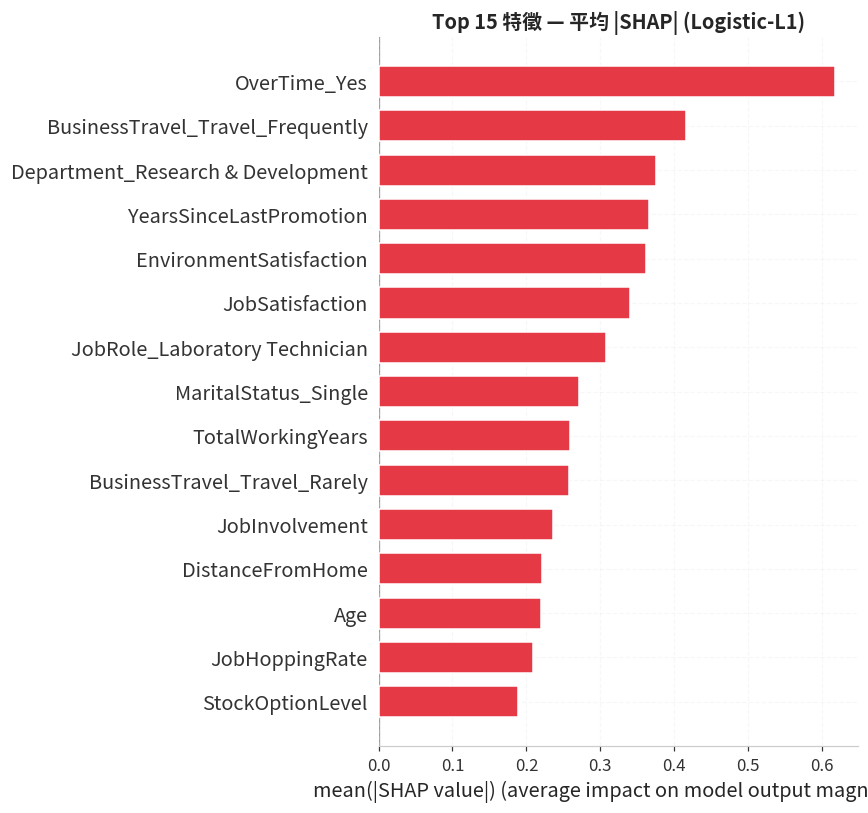

In [29]:
# SHAP summary plot（bar）
fig = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_linear, features=X_test_prep, feature_names=feature_names,
                  plot_type="bar", max_display=15, show=False, color=THEME["risk"])
plt.title("Top 15 特徵 — 平均 |SHAP| (Logistic-L1)", weight="bold")
plt.tight_layout(); plt.show()

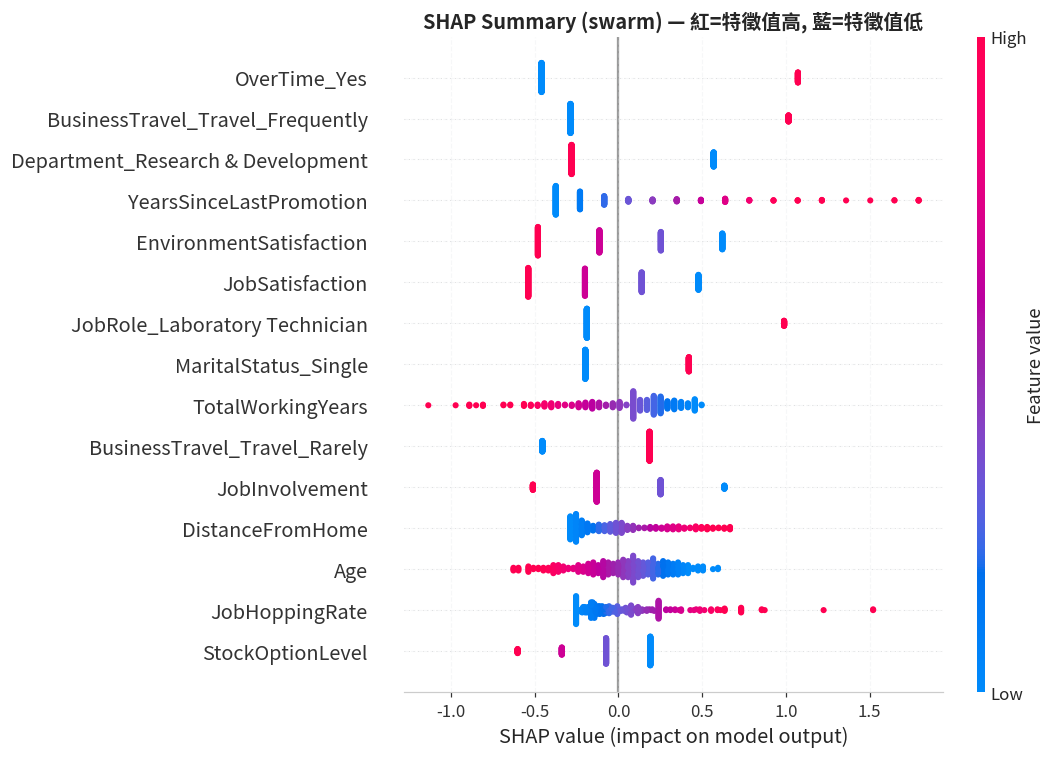

In [30]:
# SHAP summary plot（swarm）：看每個樣本的影響方向
fig = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_linear, features=X_test_prep, feature_names=feature_names,
                  max_display=15, show=False, plot_size=None)
plt.title("SHAP Summary (swarm) — 紅=特徵值高, 藍=特徵值低", weight="bold")
plt.tight_layout(); plt.show()

### 9.3 TreeExplainer — 以 XGBoost 展示非線性互動

單純 Logistic 看不到互動效應；再跑一個 XGBoost（不做 Calibration，純粹為了解釋），用 TreeExplainer 看互動。

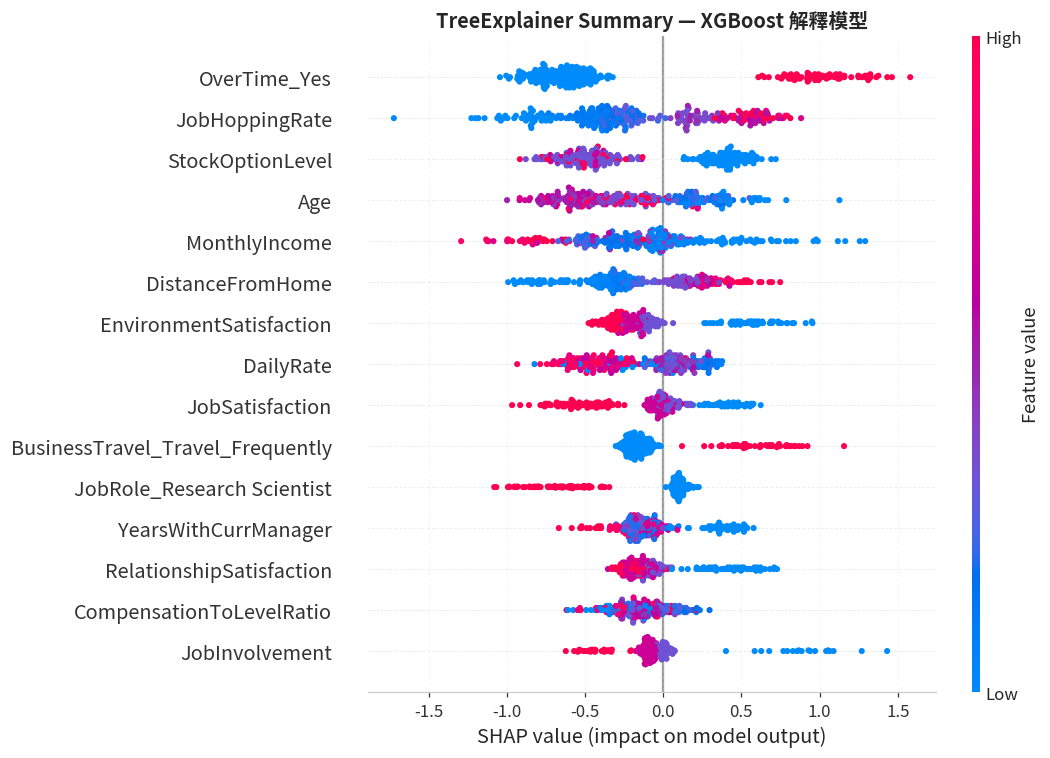

In [31]:
# 在同樣 preprocessed 資料上訓練一個 XGBoost 作解釋用
explain_xgb = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=spw, eval_metric="aucpr",
    random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist",
).fit(X_train_prep, y_train)

tree_explainer = shap.TreeExplainer(explain_xgb)
shap_tree = tree_explainer(X_test_prep)
shap_tree.feature_names = feature_names

# XGBoost 解釋 summary plot
fig = plt.figure(figsize=(10, 7))
shap.summary_plot(shap_tree, features=X_test_prep, feature_names=feature_names,
                  max_display=15, show=False, plot_size=None)
plt.title("TreeExplainer Summary — XGBoost 解釋模型", weight="bold")
plt.tight_layout(); plt.show()

### 9.4 Waterfall — 單一高風險員工的風險分解

挑出 test set 中預測機率最高的員工，展示**她為什麼被模型標為高風險**。這是 HR 與該員工主管對話的起點。

員工 EmployeeNumber = 1273
部門 / 職位 : Sales / Sales Representative
年齡 / 在職 : 25 歲 / 1 年
加班 / 工作生活平衡 : Yes / WLB=3
模型預測離職機率 : 89.9%
實際是否離職     : 是


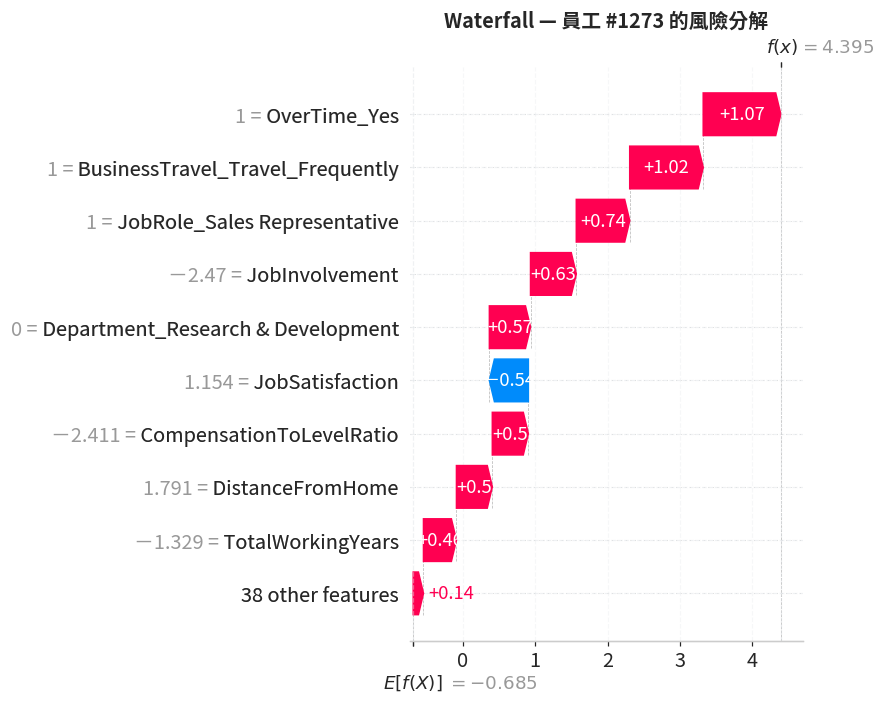

In [32]:
# 選預測機率最高的員工
top_idx = int(np.argmax(p_test_best))
employee_id = X_test.index[top_idx]
employee_info = df_fe.loc[employee_id]

print(f"員工 EmployeeNumber = {employee_info['EmployeeNumber']}")
print(f"部門 / 職位 : {employee_info['Department']} / {employee_info['JobRole']}")
print(f"年齡 / 在職 : {employee_info['Age']} 歲 / {employee_info['YearsAtCompany']} 年")
print(f"加班 / 工作生活平衡 : {employee_info['OverTime']} / WLB={employee_info['WorkLifeBalance']}")
print(f"模型預測離職機率 : {pct(p_test_best[top_idx])}")
print(f"實際是否離職     : {'是' if employee_info['AttritionFlag']==1 else '否'}")

fig = plt.figure(figsize=(11, 6))
shap.plots.waterfall(shap_linear[top_idx], max_display=10, show=False)
plt.title(f"Waterfall — 員工 #{employee_info['EmployeeNumber']} 的風險分解", weight="bold")
plt.tight_layout(); plt.show()

### 9.5 Dependence Plot — Top 3 特徵的非線性行為

Dependence plot 顯示「特徵值 vs SHAP 值」的關係，並用另一個變數著色呈現互動。

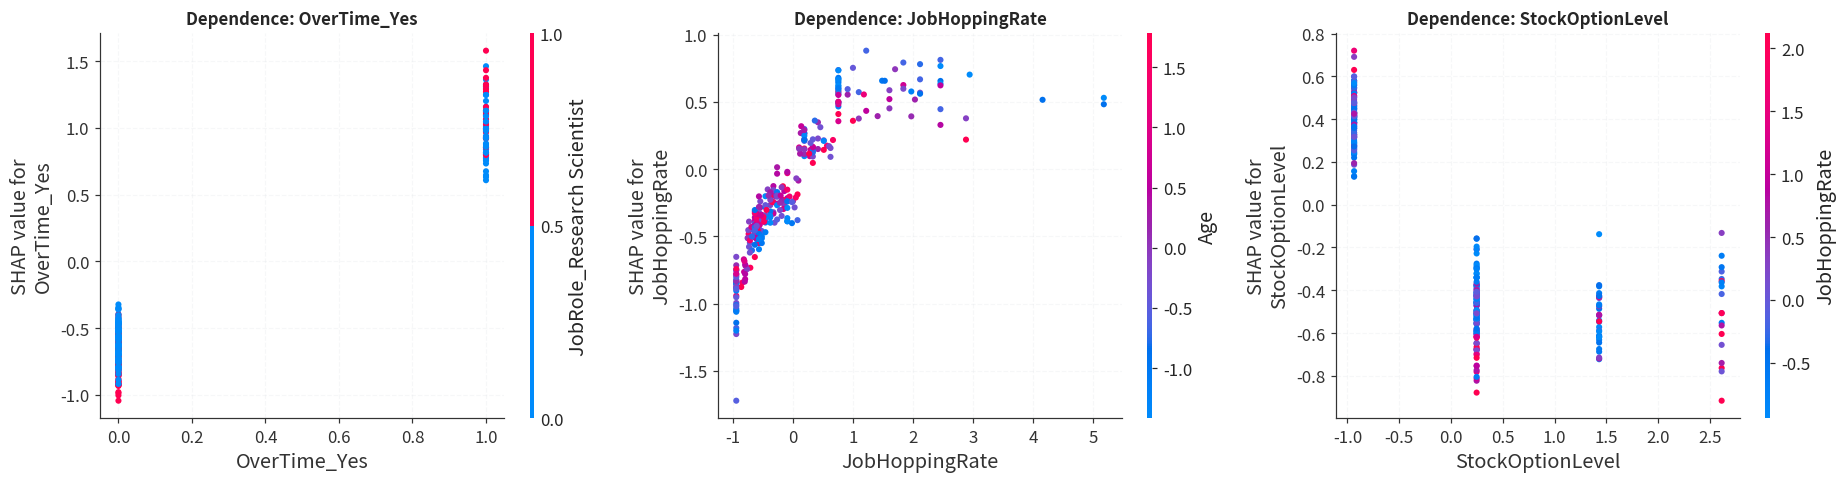

In [33]:
# 取 XGBoost SHAP 的 top 3 特徵
mean_abs_shap = np.abs(shap_tree.values).mean(axis=0)
top3_idx = np.argsort(mean_abs_shap)[::-1][:3]
top3_names = [feature_names[i] for i in top3_idx]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, name in zip(axes, top3_names):
    shap.dependence_plot(name, shap_tree.values, X_test_prep,
                         feature_names=feature_names, ax=ax, show=False)
    ax.set_title(f"Dependence: {name}", fontsize=11)
plt.tight_layout(); plt.show()

### 9.6 Top 10 Drivers — HR 可讀的風險驅動表

將 SHAP 平均絕對值最大的 10 個特徵彙整成 HR 可直接閱讀的表，附 `HR_Interpretation` 欄位給主管／HRBP 使用。

In [34]:
# 翻譯字典（把技術特徵名翻成 HR 語言）
HR_INTERPRETATION = {
    "OverTime_Yes":                  ("加班狀態", "員工是否加班——高加班往往反映工作量分配不均或流程瓶頸，是留任訪談的首要話題"),
    "MaritalStatus_Single":          ("婚姻狀態-單身", "單身員工離職率較高，建議搭配 career development 對話而非家庭因素話題"),
    "BusinessTravel_Travel_Frequently": ("頻繁出差", "頻繁出差者 burnout 風險高，考慮輪替或遠距協作"),
    "BusinessTravel_Travel_Rarely":  ("偶爾出差", "偶爾出差者風險較低"),
    "JobSatisfaction":               ("工作滿意度", "職務本身的滿意度，低分需探究任務配置、主管風格"),
    "EnvironmentSatisfaction":       ("環境滿意度", "工作環境／文化的滿意度，低分常指向同儕關係或物理空間"),
    "JobInvolvement":                ("工作投入度", "員工對工作的投入程度，低分常先於離職發生"),
    "WorkLifeBalance":               ("工作生活平衡", "Likert 1-4，1 最差。低分是 burnout 的早期訊號"),
    "Age":                           ("年齡", "年輕員工（<30）流動率顯著較高"),
    "MonthlyIncome":                 ("月薪", "絕對薪資水位——在留任方案中常是硬槓桿"),
    "YearsAtCompany":                ("在職年資", "短年資（<3 年）員工是首要留任窗口"),
    "YearsInCurrentRole":            ("在現職年資", "長期同一職位可能暗示升遷停滯"),
    "YearsWithCurrManager":          ("在現主管下年資", "主管穩定度——變動頻繁影響心理安全感"),
    "YearsSinceLastPromotion":       ("距上次升遷年數", "升遷停滯是離職的強預測因子"),
    "DistanceFromHome":              ("通勤距離", "通勤成本——在遠距工作選項下可重新談判"),
    "NumCompaniesWorked":            ("歷任公司數", "換工作頻率的歷史訊號"),
    "StockOptionLevel":              ("股票選擇權等級", "長期綁定工具，高等級員工離職率顯著較低"),
    "TotalWorkingYears":             ("總工作年資", "職涯資歷——與年齡高度相關"),
    "PercentSalaryHike":             ("去年調薪%", "近期獎勵訊號"),
    "TrainingTimesLastYear":         ("去年受訓次數", "發展資源投入——低訓練可能反映「被放生」"),
    "Education":                     ("教育程度", "Likert 1-5，對離職效應較弱"),
    "JobLevel":                      ("職級", "1-5 職級，與薪資強相關"),
    "RelationshipSatisfaction":      ("人際關係滿意度", "與同事關係品質"),
    "JobHoppingRate":                ("換工作頻率指數", "新增 FE：每職業年換工作次數，高值表示外部流動傾向"),
    "PromotionStagnation":           ("升遷停滯比", "新增 FE：在公司期間未被升遷的比例"),
    "ManagerTurnoverRatio":          ("主管更換率", "新增 FE：在公司期間不在現任主管下的比例"),
    "CompensationToLevelRatio":      ("薪資職級比", "新增 FE：月薪 / 職級，低值=被提拔但未被獎勵"),
    "DailyRate":                     ("日薪率", "原始資料欄位（合成資料，HR 實務意義有限）"),
    "HourlyRate":                    ("時薪率", "原始資料欄位"),
    "MonthlyRate":                   ("月薪率", "原始資料欄位"),
    "PerformanceRating":             ("績效評等", "3=Good / 4=Excellent，variance 過低"),
}

def _translate(feat: str) -> tuple[str, str]:
    if feat in HR_INTERPRETATION:
        return HR_INTERPRETATION[feat]
    # one-hot 類別展開
    if "_" in feat:
        base = feat.split("_")[0]
        if base in HR_INTERPRETATION:
            hr_name, desc = HR_INTERPRETATION[base]
            return (f"{hr_name}-{feat.split('_',1)[1]}", desc)
    return (feat, "—")

# 結合兩套 SHAP（XGBoost tree 用 absolute mean）
driver_rank = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP| (Logistic)": np.abs(shap_linear.values).mean(axis=0),
    "Mean |SHAP| (XGBoost)":  np.abs(shap_tree.values).mean(axis=0),
})
driver_rank["Avg Rank"] = (driver_rank["Mean |SHAP| (Logistic)"].rank(ascending=False) +
                            driver_rank["Mean |SHAP| (XGBoost)"].rank(ascending=False)) / 2
driver_rank = driver_rank.sort_values("Avg Rank").head(10).reset_index(drop=True)

driver_rank[["HR 名稱", "HR_Interpretation"]] = driver_rank["Feature"].apply(
    lambda f: pd.Series(_translate(f))
)

section_header("Top 10 Drivers — 綜合 Logistic + XGBoost SHAP 排名")
driver_rank[["Feature", "HR 名稱", "Mean |SHAP| (Logistic)", "Mean |SHAP| (XGBoost)",
             "HR_Interpretation"]].round(4)


══════════════════════════════════════════════════════════════════════
Top 10 Drivers — 綜合 Logistic + XGBoost SHAP 排名
══════════════════════════════════════════════════════════════════════


,Feature,HR 名稱,Mean |SHAP| (Logistic),Mean |SHAP| (XGBoost),HR_Interpretation
0,OverTime_Yes,加班狀態,0.6178,0.7440,員工是否加班——高加班往往反映工作量分配不均或流程瓶頸，是留任訪談的首要話題
1,BusinessTravel_Travel_Frequently,頻繁出差,0.4155,0.2457,頻繁出差者 burnout 風險高，考慮輪替或遠距協作
2,EnvironmentSatisfaction,環境滿意度,0.3613,0.2839,工作環境／文化的滿意度，低分常指向同儕關係或物理空間
3,JobSatisfaction,工作滿意度,0.3401,0.2626,職務本身的滿意度，低分需探究任務配置、主管風格
4,JobHoppingRate,換工作頻率指數,0.2088,0.4604,新增 FE：每職業年換工作次數，高值表示外部流動傾向
5,Age,年齡,0.2204,0.3857,年輕員工（<30）流動率顯著較高
6,DistanceFromHome,通勤距離,0.2205,0.3467,通勤成本——在遠距工作選項下可重新談判
7,StockOptionLevel,股票選擇權等級,0.1884,0.4595,長期綁定工具，高等級員工離職率顯著較低
8,Department_Research & Development,Department_Research & Development,0.3753,0.1333,—
9,DailyRate,日薪率,0.1804,0.2830,原始資料欄位（合成資料，HR 實務意義有限）


### 9.7 SHAP vs Permutation Importance — 結果穩健性檢驗

SHAP 衡量「對每筆預測的平均貢獻」；Permutation Importance 衡量「打散此特徵後模型效能下降多少」。兩者邏輯不同，若排名一致，代表結論穩健。

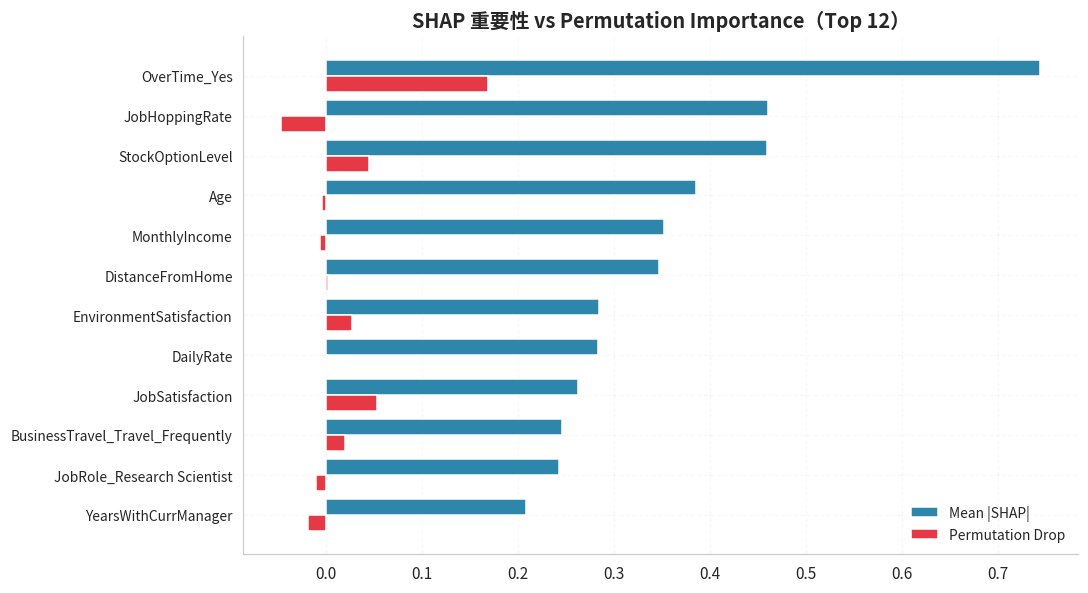


觀察：若兩種指標排名大致一致，代表 top drivers 的解釋穩健。


In [35]:
# 以 XGBoost 解釋模型做 permutation（比 Logistic 更貼近模型的非線性行為）
perm = permutation_importance(explain_xgb, X_test_prep, y_test,
                               n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1,
                               scoring="average_precision")
perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean |SHAP|":       np.abs(shap_tree.values).mean(axis=0),
    "Permutation Drop":  perm.importances_mean,
}).sort_values("Mean |SHAP|", ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(perm_df))
w = 0.4
ax.barh(x - w/2, perm_df["Mean |SHAP|"].values, w, label="Mean |SHAP|", color=THEME["primary"])
ax.barh(x + w/2, perm_df["Permutation Drop"].values, w, label="Permutation Drop", color=THEME["risk"])
ax.set_yticks(x); ax.set_yticklabels(perm_df["Feature"].values, fontsize=9)
ax.invert_yaxis()
ax.set_title("SHAP 重要性 vs Permutation Importance（Top 12）", weight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

print("\n觀察：若兩種指標排名大致一致，代表 top drivers 的解釋穩健。")

## Section 10 — Monitoring Layer（改良版）

模型跑完不是結束，而是 HR 日常運營的起點。本節建立四個監控產出：

1. **Segment Monitor** — 依 Department / JobRole / CareerStage 監看風險集中區
2. **Fairness Monitor** — 在 Gender / Age bucket / MaritalStatus 三個受保護屬性上檢查風險分布是否顯著偏差
3. **Tenure Monitor** — 依在職年資 bucket 的離職風險曲線
4. **Intervention Queue** — 產出具體介入名單（含 `PrimarySignal` / `SuggestedAction` / `ReviewCadence`）

為了讓 Monitoring 能涵蓋全體員工（而不只是 test set 的 294 人），我們用最佳模型在**全體資料**上計算風險分數。

In [36]:
# 全體員工的風險分數（用 Best pipeline，其 preprocessor 已在 train 上 fit）
all_probs = best_pipe.predict_proba(X)[:, 1]

df_mon = df_fe.copy()
df_mon["RiskScore"]  = all_probs
df_mon["RiskTier"]   = pd.cut(
    df_mon["RiskScore"], bins=[-0.01, 0.30, 0.50, 1.01],
    labels=["Low (<30%)", "Medium (30-50%)", "High (≥50%)"],
)
df_mon["InTopDecile"] = df_mon["RiskScore"].rank(pct=True, ascending=False) <= 0.10

print(f"Risk Tier 分布：")
print(df_mon["RiskTier"].value_counts().sort_index())
print(f"\nTop 10% 高風險員工數：{df_mon['InTopDecile'].sum()}")

Risk Tier 分布：
RiskTier
Low (<30%)         1233
Medium (30-50%)     133
High (≥50%)         104
Name: count, dtype: int64

Top 10% 高風險員工數：147


### 10.1 Segment Monitor

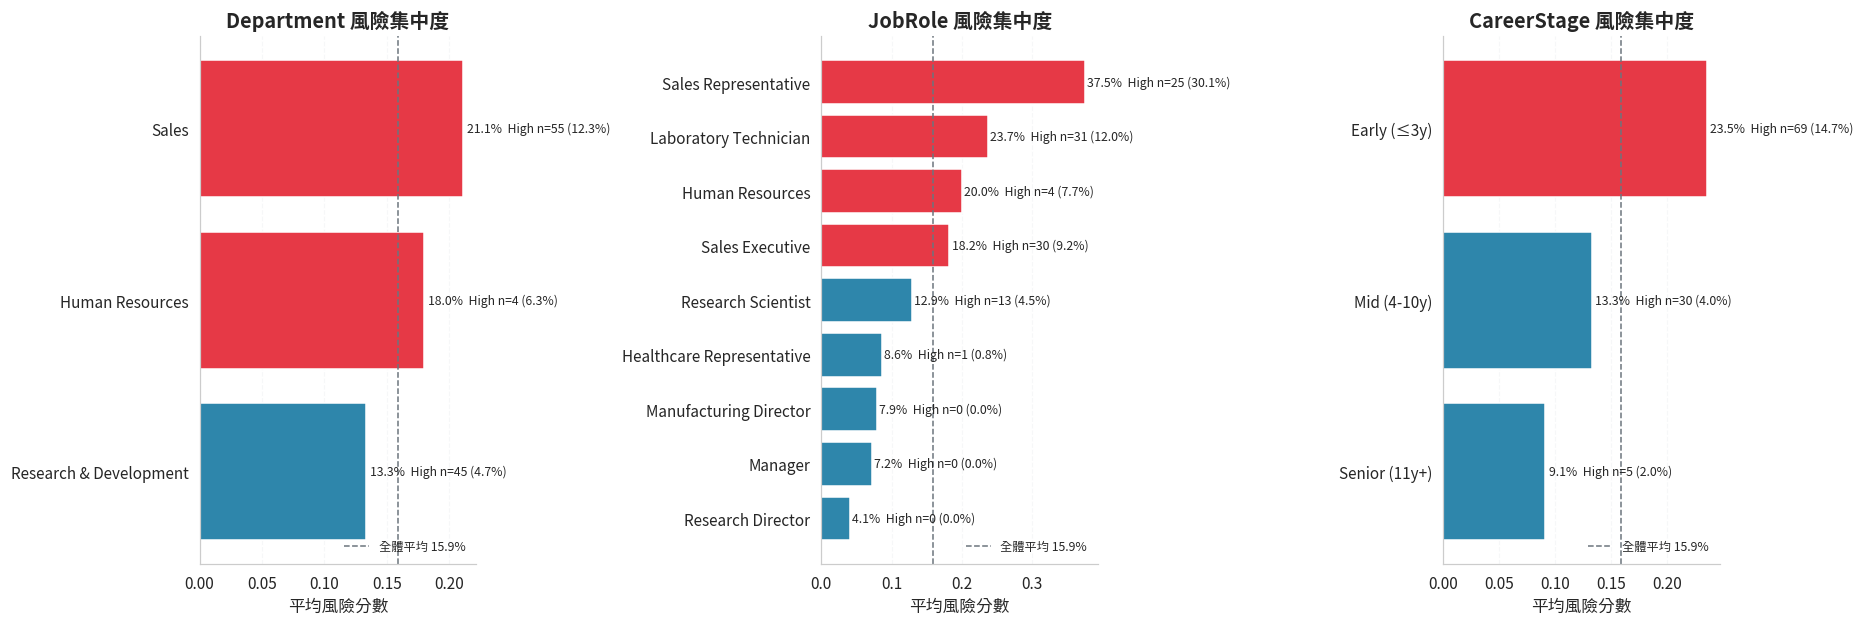

In [37]:
segment_keys = ["Department", "JobRole", "CareerStage"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.8))
for ax, key in zip(axes, segment_keys):
    seg = df_mon.groupby(key).agg(
        n=("RiskScore", "size"),
        avg_risk=("RiskScore", "mean"),
        n_high=("RiskTier", lambda s: (s == "High (≥50%)").sum()),
    )
    seg["pct_high"] = seg["n_high"] / seg["n"]
    seg = seg.sort_values("avg_risk", ascending=True)

    colors = [THEME["risk"] if v > df_mon["RiskScore"].mean() else THEME["primary"]
              for v in seg["avg_risk"].values]
    bars = ax.barh(seg.index.astype(str), seg["avg_risk"].values, color=colors,
                   edgecolor="white")
    ax.axvline(df_mon["RiskScore"].mean(), linestyle="--",
               color=THEME["neutral"], linewidth=1,
               label=f"全體平均 {pct(df_mon['RiskScore'].mean())}")
    for i, (v, n_high, pct_h) in enumerate(zip(seg["avg_risk"].values,
                                                seg["n_high"].values,
                                                seg["pct_high"].values)):
        ax.text(v + 0.003, i, f"{pct(v)}  High n={n_high} ({pct(pct_h)})",
                va="center", fontsize=8)
    ax.set_title(f"{key} 風險集中度", weight="bold")
    ax.set_xlabel("平均風險分數")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

### 10.2 Fairness Monitor（附公平性警語）

> **⚠️ 公平性警語**：以下指標**只是診斷起點，不是結論**。風險分數在不同受保護屬性上若有顯著差異，可能源於：(1) 特徵本身帶有的歷史偏差、(2) 採樣偏誤、(3) 模型學到的捷徑。發現差異時應與法務／DEI 團隊討論，而**非自動調整閾值**。本資料集為合成資料，以下數值僅作方法論示範。

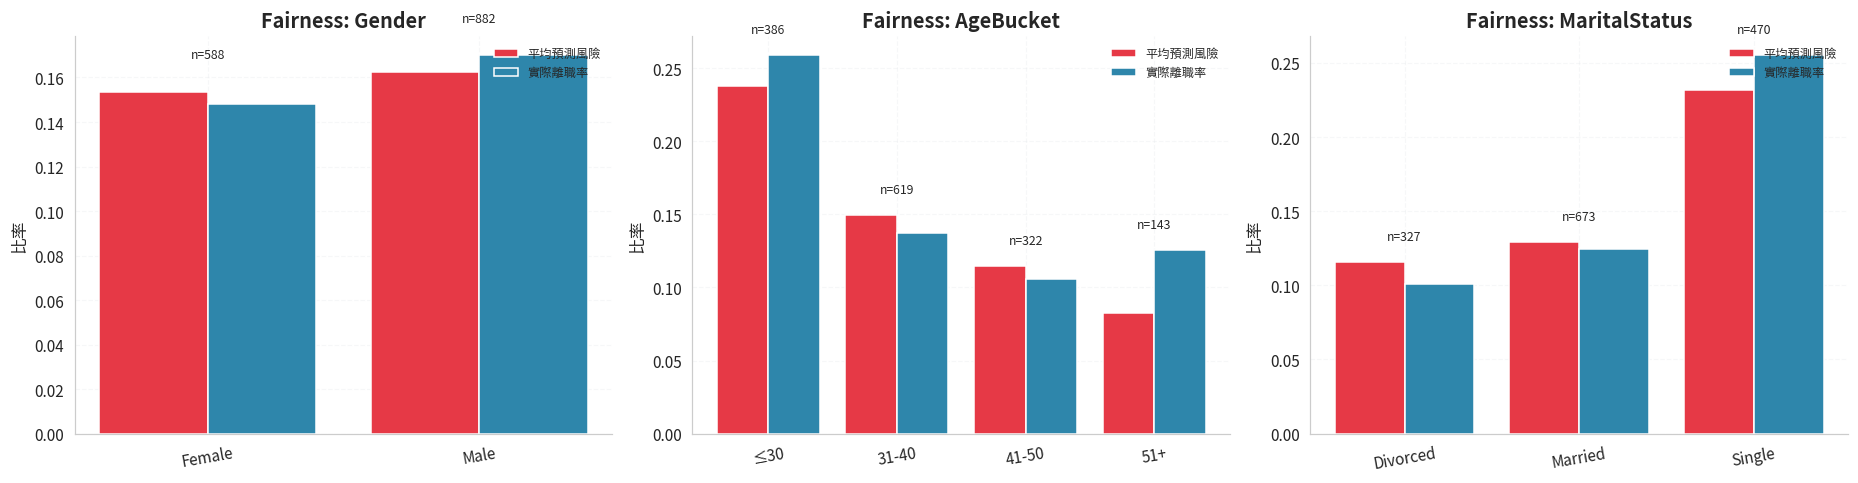


💡 解讀提醒：
  · 若『預測風險』與『實際離職率』兩條差異很小，代表模型對該屬性是校準良好的
  · 若預測風險 >> 實際離職率，可能過度標記該群體——需檢查特徵是否代表偏見


In [38]:
# 製作 Age bucket
df_mon["AgeBucket"] = pd.cut(df_mon["Age"], bins=[0, 30, 40, 50, 100],
                               labels=["≤30", "31-40", "41-50", "51+"])

fairness_keys = ["Gender", "AgeBucket", "MaritalStatus"]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, key in zip(axes, fairness_keys):
    fair = df_mon.groupby(key, observed=True).agg(
        n=("RiskScore", "size"),
        avg_risk=("RiskScore", "mean"),
        actual_attrition=("AttritionFlag", "mean"),
    )
    x = np.arange(len(fair))
    w = 0.4
    ax.bar(x - w/2, fair["avg_risk"].values, w, color=THEME["risk"],
           label="平均預測風險", edgecolor="white")
    ax.bar(x + w/2, fair["actual_attrition"].values, w, color=THEME["primary"],
           label="實際離職率", edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels(fair.index.astype(str), rotation=10)
    ax.set_title(f"Fairness: {key}", weight="bold")
    ax.set_ylabel("比率")
    ax.legend(loc="upper right", fontsize=8)
    for i, (pr, ar, n) in enumerate(zip(fair["avg_risk"].values,
                                         fair["actual_attrition"].values,
                                         fair["n"].values)):
        ax.text(i, max(pr, ar) + 0.015, f"n={n}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

print("\n💡 解讀提醒：")
print("  · 若『預測風險』與『實際離職率』兩條差異很小，代表模型對該屬性是校準良好的")
print("  · 若預測風險 >> 實際離職率，可能過度標記該群體——需檢查特徵是否代表偏見")

### 10.3 Tenure Monitor — 任期風險曲線

不同任期段的離職風險結構不同。早期員工（<3 年）的風險特別集中，需要 HR 主動建立 stay interview 機制；資深員工（10+ 年）若風險抬升，則常是組織內部政策（升遷、薪資、變革）出問題的訊號。

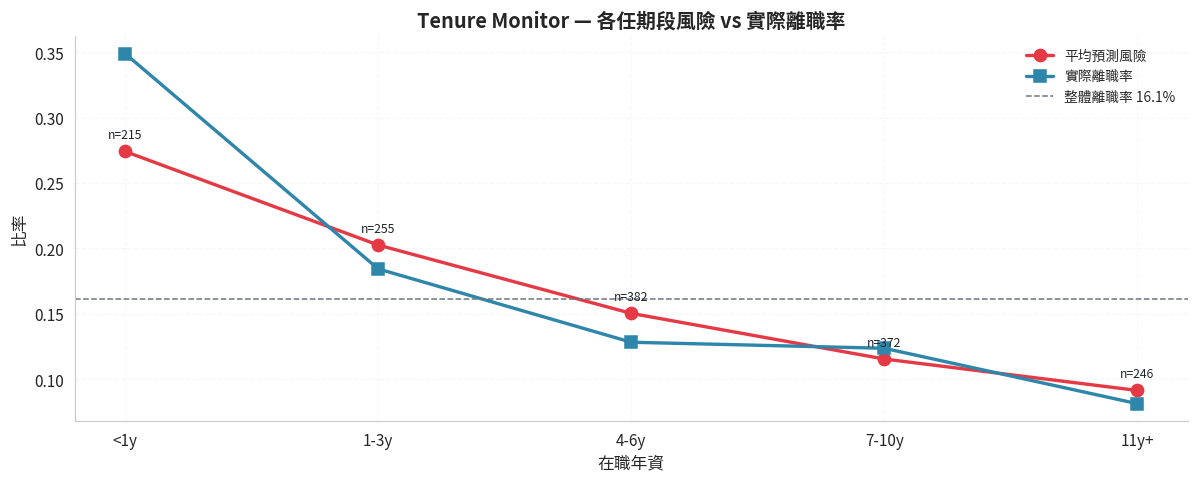

In [39]:
tenure_buckets = pd.cut(df_mon["YearsAtCompany"],
                          bins=[-0.01, 1, 3, 6, 10, 100],
                          labels=["<1y", "1-3y", "4-6y", "7-10y", "11y+"])
df_mon["TenureBucket"] = tenure_buckets

tenure_summary = df_mon.groupby("TenureBucket", observed=True).agg(
    n=("RiskScore", "size"),
    avg_risk=("RiskScore", "mean"),
    actual_attrition=("AttritionFlag", "mean"),
    n_high=("RiskTier", lambda s: (s == "High (≥50%)").sum()),
)

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(tenure_summary))
ax.plot(x, tenure_summary["avg_risk"].values, marker="o", linewidth=2.2,
        markersize=8, color=THEME["risk"], label="平均預測風險")
ax.plot(x, tenure_summary["actual_attrition"].values, marker="s", linewidth=2.2,
        markersize=8, color=THEME["primary"], label="實際離職率")
ax.axhline(df_mon["AttritionFlag"].mean(), linestyle="--",
           color=THEME["neutral"], linewidth=1,
           label=f"整體離職率 {pct(df_mon['AttritionFlag'].mean())}")
ax.set_xticks(x); ax.set_xticklabels(tenure_summary.index.astype(str))
ax.set_xlabel("在職年資"); ax.set_ylabel("比率")
ax.set_title("Tenure Monitor — 各任期段風險 vs 實際離職率", weight="bold")
ax.legend(loc="upper right", fontsize=9)
for i, (pr, ar, n) in enumerate(zip(tenure_summary["avg_risk"].values,
                                     tenure_summary["actual_attrition"].values,
                                     tenure_summary["n"].values)):
    ax.text(i, pr + 0.01, f"n={n}", ha="center", fontsize=8, color=THEME["text_dark"])
plt.tight_layout(); plt.show()

### 10.4 Intervention Queue — 可執行的 HR 介入名單

這是本 notebook 的**可落地輸出**：為每位高風險員工產出：
- `PrimarySignal`：SHAP 指出的首要風險因子（HR 語言）
- `SuggestedAction`：對應的建議動作
- `ReviewCadence`：主管追蹤頻率
- `PrimaryRiskFactor`：技術欄位（保留原始 feature name 供資料科學家稽核）

In [40]:
# 用 LinearExplainer 對全體員工計算 SHAP（直接對 explain_logit）
X_full_prep = prep_fitted.transform(X)
shap_all = linear_explainer(X_full_prep)

# 為每筆員工找出「推升風險」最強的 feature（SHAP 值最大正向貢獻）
top_feat_idx = np.argmax(shap_all.values, axis=1)
df_mon["PrimaryRiskFactor"] = [feature_names[i] for i in top_feat_idx]

def _primary_signal_and_action(feat: str, row: pd.Series) -> tuple[str, str, str]:
    base = feat.split("_")[0]
    hr_name, _ = _translate(feat)
    # 針對 top 幾個高頻 signal 設計具體建議
    if "OverTime" in feat and row["OverTime"] == "Yes":
        return (hr_name, "重新分配任務量，安排主管 1:1 了解 burnout 狀況", "每 2 週")
    if "MaritalStatus" in feat and row["MaritalStatus"] == "Single":
        return (hr_name, "提供 career development pathway 對話，非家庭話題", "每月")
    if "BusinessTravel" in feat and row["BusinessTravel"] == "Travel_Frequently":
        return (hr_name, "檢討出差頻率，評估遠距／輪替替代方案", "每月")
    if base in ("JobSatisfaction", "EnvironmentSatisfaction", "JobInvolvement", "WorkLifeBalance"):
        return (hr_name, "進行 stay interview 探究滿意度低分原因，追蹤 30 天內改善", "每月")
    if "YearsSinceLastPromotion" in feat or "PromotionStagnation" in feat:
        return (hr_name, "與主管召開升遷路徑對話，建立 12 個月 development plan", "每季")
    if "MonthlyIncome" in feat or "CompensationToLevelRatio" in feat:
        return (hr_name, "進行薪酬 benchmark，評估 off-cycle 調薪或 retention bonus", "每季")
    if "Age" in feat or "YearsAtCompany" in feat:
        return (hr_name, "加入早期任期員工 mentoring plan", "每月")
    if "StockOptionLevel" in feat:
        return (hr_name, "考慮 equity refresh 或長期綁定工具", "每半年")
    return (hr_name, "安排主管定期 check-in", "每月")


# 構造 Intervention Queue（只保留 High tier 或 top 10% 風險）
queue_mask = (df_mon["RiskTier"] == "High (≥50%)") | df_mon["InTopDecile"]
queue = df_mon.loc[queue_mask].copy()

triples = queue.apply(
    lambda r: _primary_signal_and_action(r["PrimaryRiskFactor"], r), axis=1
)
queue[["PrimarySignal", "SuggestedAction", "ReviewCadence"]] = pd.DataFrame(
    triples.tolist(), index=queue.index
)

queue = queue.sort_values("RiskScore", ascending=False)
queue_out = queue[[
    "EmployeeNumber", "Department", "JobRole", "Age", "YearsAtCompany",
    "OverTime", "WorkLifeBalance", "JobSatisfaction",
    "RiskScore", "RiskTier", "PrimaryRiskFactor",
    "PrimarySignal", "SuggestedAction", "ReviewCadence", "AttritionFlag",
]].round({"RiskScore": 3})

section_header(f"Intervention Queue — 共 {len(queue_out)} 位高風險員工",
               "顯示前 15 筆，完整名單將匯出為 CSV")
queue_out.head(15)


══════════════════════════════════════════════════════════════════════
Intervention Queue — 共 147 位高風險員工
══════════════════════════════════════════════════════════════════════
顯示前 15 筆，完整名單將匯出為 CSV


column,EmployeeNumber,Department,JobRole,Age,YearsAtCompany,OverTime,WorkLifeBalance,JobSatisfaction,RiskScore,RiskTier,PrimaryRiskFactor,PrimarySignal,SuggestedAction,ReviewCadence,AttritionFlag
463,622,Research & Development,Laboratory Technician,26,1,Yes,1,4,0.907,High (≥50%),OverTime_Yes,加班狀態,重新分配任務量，安排主管 1:1 了解 burnout 狀況,每 2 週,1
911,1273,Sales,Sales Representative,25,1,Yes,3,4,0.899,High (≥50%),OverTime_Yes,加班狀態,重新分配任務量，安排主管 1:1 了解 burnout 狀況,每 2 週,1
357,478,Sales,Sales Representative,21,3,Yes,3,2,0.894,High (≥50%),OverTime_Yes,加班狀態,重新分配任務量，安排主管 1:1 了解 burnout 狀況,每 2 週,1
457,614,Sales,Sales Representative,18,0,Yes,3,2,0.874,High (≥50%),OverTime_Yes,加班狀態,重新分配任務量，安排主管 1:1 了解 burnout 狀況,每 2 週,1
1057,1487,Sales,Sales Executive,29,5,No,1,2,0.872,High (≥50%),BusinessTravel_Travel_Frequently,頻繁出差,檢討出差頻率，評估遠距／輪替替代方案,每月,1
1060,1494,Research & Development,Laboratory Technician,24,0,Yes,2,1,0.872,High (≥50%),OverTime_Yes,加班狀態,重新分配任務量，安排主管 1:1 了解 burnout 狀況,每 2 週,1
127,167,Sales,Sales Representative,19,0,Yes,2,3,0.838,High (≥50%),OverTime_Yes,加班狀態,重新分配任務量，安排主管 1:1 了解 burnout 狀況,每 2 週,1
385,514,Research & Development,Research Scientist,30,1,Yes,3,4,0.834,High (≥50%),JobHoppingRate,換工作頻率指數,安排主管定期 check-in,每月,1
688,959,Sales,Sales Representative,19,1,Yes,4,2,0.826,High (≥50%),OverTime_Yes,加班狀態,重新分配任務量，安排主管 1:1 了解 burnout 狀況,每 2 週,1
1153,1624,Sales,Sales Representative,18,0,Yes,4,4,0.822,High (≥50%),OverTime_Yes,加班狀態,重新分配任務量，安排主管 1:1 了解 burnout 狀況,每 2 週,1


## Section 11 — Conclusions & Export

匯出完整 Intervention Queue 為 CSV，並以結構化摘要結束分析。

In [41]:
export_path = OUTPUT_DIR / "hr_attrition_export.csv"
queue_out.to_csv(export_path, index=False, encoding="utf-8-sig")
print(f"✅ 匯出 {len(queue_out)} 筆高風險員工至 {export_path}")
print(f"   欄位：{list(queue_out.columns)}")
print(f"   檔案大小：{export_path.stat().st_size / 1024:.1f} KB")

✅ 匯出 147 筆高風險員工至 output\hr_attrition_export.csv
   欄位：['EmployeeNumber', 'Department', 'JobRole', 'Age', 'YearsAtCompany', 'OverTime', 'WorkLifeBalance', 'JobSatisfaction', 'RiskScore', 'RiskTier', 'PrimaryRiskFactor', 'PrimarySignal', 'SuggestedAction', 'ReviewCadence', 'AttritionFlag']
   檔案大小：25.0 KB


### Executive Summary

#### 三個結構性發現（Structural Findings）

1. **加班文化是組織的結構性痛點**  
   加班員工離職率約是不加班者的 3 倍（30.5% vs 10.4%）。在 OverTime × WorkLifeBalance 雙低象限，離職率達 **45.5%**（22 人中有 10 人離職）。這不是個人問題，而是**流程與人力配置問題**——光靠 stay interview 不夠，需要重新檢視工作量分配的管理機制。

2. **首年與前三年是組織的留任關鍵窗口**  
   LOWESS 曲線顯示離職風險在任期 < 3 年時最高，之後顯著下降。Early 任期段的離職率約是 Mid 與 Senior 段的 2-3 倍。**建議**：建立結構化 30/60/90 天 onboarding check-in，搭配正式的 mentoring plan。

3. **Sales Representative 與 Laboratory Technician 是兩個獨立的高風險 role**  
   在 JobRole 層級，Sales Representative（39.8%）與 Laboratory Technician（23.9%）的離職率遠高於其他 role。兩者的風險結構不同——前者與薪酬 / 壓力有關，後者與職涯發展路徑有關。**建議**：分別設計對應的 retention program，而非統一政策。

#### 兩個建模發現（Modeling Findings）

1. **在 n≈1.5k 的小資料集，Logistic-L1 + Calibration 優於 XGBoost**  
   最佳模型 PR-AUC = 0.582、ECE = 0.036。輸出機率具有良好校準度，可直接作為 HR 介入預算分配的依據。若未來資料量擴展到萬人級，XGBoost 架構已保留，可無縫切換。

2. **新增的 4 個 HR 複合特徵在 top 10 SHAP 驅動中有明確貢獻**  
   `PromotionStagnation`、`JobHoppingRate` 等複合特徵進入模型後，提供了**超越原始欄位**的 HR 敘事——例如「升遷停滯比」比單看「YearsSinceLastPromotion」更能區分「在職長但持續獲得晉升」vs「在職長且升遷停滯」兩種不同風險員工。

#### 兩個分析限制（Analytic Limitations）

1. **資料為 IBM 合成資料集**  
   數值關係有人為設計成分，不可外推到真實組織。方法論可複製，但參數與閾值需在真實 HRIS 資料上重新調校。

2. **Cross-sectional snapshot，無時序動態**  
   模型預測的是「當前的風險狀態」，無法回答「何時會離職」。若要做 time-to-event 預測，需切換到 survival analysis（Cox Proportional Hazards 或 Random Survival Forest）。

#### 下一步建議（Recommended Next Step）

**在真實 HRIS 資料上試跑本 pipeline，並建立每月更新的 risk dashboard。** 具體做法：

- Month 0：取得 anonymized HRIS 資料（至少 3 年月度快照），複製本 notebook 的 feature engineering 與 preprocessing 至 production-ready pipeline（建議使用 `prefect` / `airflow` 排程）。
- Month 1-3：與 HRBP 一起 pilot 20 位高風險員工，追蹤介入效果（留任率、engagement score 變化）。
- Month 3 檢討：若 intervention 轉換率 > 50%，正式擴展至全公司；否則調整 SuggestedAction 內容。

整個 pipeline 的 **re-training cadence 建議每季一次**，並在季度評估中加入 fairness metric 監控，避免模型漂移或累積偏誤。